In [2]:
import sys
sys.path.append("../cluster/")
sys.path.append("../python/")

import matplotlib.pyplot as plt
import pickle
import numpy as np
from _corner import corner
from scipy.stats import binned_statistic, gaussian_kde

from matplotlib import rc
rc('font',**{'family':'sans-serif', 'size':22})

# First step: create mock observation of Brown Dwarfs

In [29]:
from mock_generation import mock_population

In [30]:
robs1, sigmarobs1, Tobs1, sigmaTobs1, Mobs1, sigmaMobs1, Aobs1, sigmaAobs1 = mock_population(
100, 0.1, 0., 0., 0., 1., 1.2, 10., rho0_true=0.42, Tmin=650., v=100)

In [31]:
robs2, sigmarobs2, Tobs2, sigmaTobs2, Mobs2, sigmaMobs2, Aobs2, sigmaAobs2 = mock_population(
1000, 0.1, 0., 0., 0., 1., 1.2, 10., rho0_true=0.42, Tmin=650., v=100)

In [32]:
from mock_generation import IMF_sampling
from astropy.constants import M_jup, M_sun
import numpy as np

In [33]:
mass1 = IMF_sampling(-0.6, 100, Mmin=6, Mmax=75)
mass1 = mass1*M_jup.value/M_sun.value
mass2 = IMF_sampling(-0.6, 1000, Mmin=6, Mmax=75)
mass2 = mass2*M_jup.value/M_sun.value

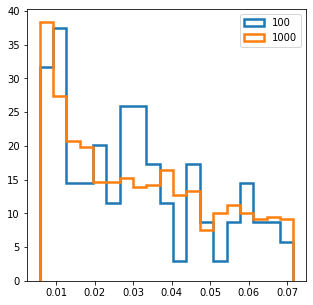

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
bins = np.linspace(6*M_jup.value/M_sun.value, 75*M_jup.value/M_sun.value, 20)
ax.hist(mass1, histtype="step", lw=2.5, density=True, bins=bins, label="100"); 
ax.hist(mass2, histtype="step", lw=2.5, density=True, bins=bins, label="1000"); ax.legend()

In [19]:
np.random.seed(1)
robs1, sigmarobs1, Tobs1, sigmaTobs1, Mobs1, sigmaMobs1, Aobs1, sigmaAobs1 = mock_population(
100, 0.1, 0., 0., 0., 1., 1.2, 10., rho0_true=0.42, Tmin=650., v=100)

#print(Mobs)

np.random.seed(1)
robs, sigmarobs, Tobs, sigmaTobs, Mobs, sigmaMobs, Aobs, sigmaAobs = mock_population(
100, 0.1, 0., 0., 0., 1., 1.2, 10., rho0_true=0.42, Tmin=650., v=100)

#print(Mobs)

# Second step: Input observation into fitting algorithm & running it

In [3]:
from scipy.interpolate import griddata, interp1d
import numpy as np
from emcee_functions import lnprob
import emcee

In [20]:
# Load theoretical cooling model                                                   
path = "/home/mariacst/exoplanets/running/data/"                                   
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)               
points = np.transpose(data[0:2, :])                                                
values = data[2] 
## calculate predictic intrinsic temperature                                       
xi       = np.transpose(np.asarray([Aobs1, Mobs1]))                                  
Teff     = griddata(points, values, xi)


# Load variables analytical derivatives Tint                                       
masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)             
ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)                  
a_interp = interp1d(masses, a)                                                     
b_interp = interp1d(masses, b)                                                     
c_interp = interp1d(ages, c)                                                       
masses, b1 = np.genfromtxt(path + "dderv_ana_wrt_AM.dat", unpack=True)             
b1_interp  = interp1d(masses, b1)                                                  
ages, c1  = np.genfromtxt(path + "dderv_ana_wrt_MA.dat", unpack=True)              
c1_interp = interp1d(ages, c1)  

In [21]:
ndim     = 3                                                                       
nwalkers = 150                                                                     
# first guess                                                                      
p0 = [[0.9, 0.9, 20.] + 1e-4*np.random.randn(ndim) for j in range(nwalkers)]    
                                                                                   
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob,                            
              args=(robs1, sigmarobs1, Mobs1, sigmaMobs1, Aobs1, sigmaAobs1, Tobs1,    
                    sigmaTobs1, Teff, a_interp, b_interp, b1_interp,                
                    c_interp, c1_interp, 100.),                                       
              moves=[(emcee.moves.DEMove(), 0.8),                                  
                     (emcee.moves.DESnookerMove(), 0.2)])

In [22]:
pos, prob, state = sampler.run_mcmc(p0, 200, progress=True) 
sampler.reset()

100%|██████████| 200/200 [01:21<00:00,  2.44it/s]


In [24]:
pos, prob, state = sampler.run_mcmc(pos, 6000, progress=True)

100%|██████████| 6000/6000 [45:42<00:00,  2.19it/s] 


In [26]:
print(sampler.get_autocorr_time()[0]) 

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 120;
tau: [ 26.19706423  83.35368486 120.31119307]

In [27]:
samples = sampler.flatchain

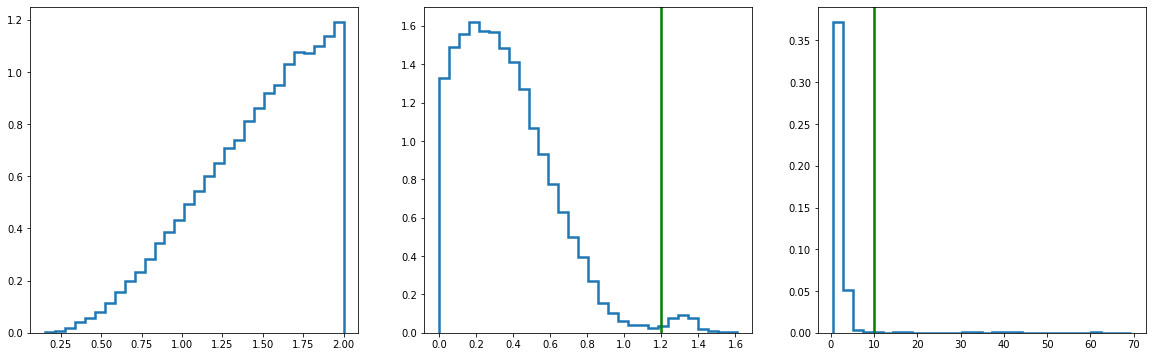

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
ax[0].hist(samples[:, 0], histtype="step", density=True, lw=2.5, bins=30); 
ax[1].hist(samples[:, 1], histtype="step", density=True, lw=2.5, bins=30); ax[1].axvline(1.2, color="green", lw=2.5)
ax[2].hist(samples[:, 2], histtype="step", density=True, lw=2.5, bins=30); ax[2].axvline(10., color="green", lw=2.5)

In [5]:
rank=900

mean       = np.zeros((4, rank))                                         
median     = np.zeros((4, rank))                                                                                     
MAP        = np.zeros((4, rank))                                           
ML         = np.zeros((4, rank)) 
FSE_mean = []; FSE_median = []; FSE_MAP = []; FSE_ML = [];
             
filepath = "/hdfs/local/mariacst/exoplanets/results/onlySigmaT/"

ex = ["Tcut_onlySigmaT"]#"onlySigmaT"
N  = [100, 1000]
   
j=0; k=1; true=1.2
for e in ex:
    for nBDs in N:
        if nBDs==100:
            nwalkers=300; steps=9000
        else:
            nwalkers=150; steps=6000
        for i in range(rank):   
            print(i+101)
            # load posterior + likelihood                                           
            file_name  = (filepath + "posterior/N%i/posterior_"%nBDs  + e +                                                     
                         ("_N%i_sigma0.1_gamma1.2rs10.0_nwalkers%i_steps%i_v%i"%(nBDs, nwalkers, steps, i+101)))                      
            samples    = pickle.load(open(file_name, "rb"))                         
            file_name2 = (filepath + "likelihood/N%i/like_"%nBDs + e +                                                     
                         ("_N%i_sigma0.01_gamma1.2rs10.0_nwalkers%i_steps%i_v%i"%(nBDs, nwalkers, steps, i+101)))                      
            like       = pickle.load(open(file_name2, "rb"))                        
                                                                                                                                             
            mean[j][i]   = np.mean(samples[:, k])                               
            median[j][i] = np.percentile(samples[:, k], [50], axis=0)                    
            #TODO need to change # bins to see if results differ                
            _n, _bins    = np.histogram(samples[:, k], bins=50)                 
            MAP[j][i]    = _bins[np.argmax(_n)]                                 
            ML[j][i]     = samples[:, k][np.argmax(like)] 
        FSE_mean.append(np.sqrt(1/rank*np.sum(np.power(mean[j] - true, 2)))/true)
        FSE_median.append(np.sqrt(1/rank*np.sum(np.power(median[j] - true, 2)))/true)
        FSE_MAP.append(np.sqrt(1/rank*np.sum(np.power(MAP[j] - true, 2)))/true)
        FSE_ML.append(np.sqrt(1/rank*np.sum(np.power(ML[j] - true, 2)))/true)
        print(j, e, nBDs)        
        j+=1       

101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
300
301
302
303
304
305
306
307
308
309
310
311
312
313
314
315
316
317
318
319
320
321
322
323
324
325
326
327
328
329
330
331
332
333
334
335
336
337
338
339
340
341
342
343
344
345
346
347
348
349
350


0
4
8


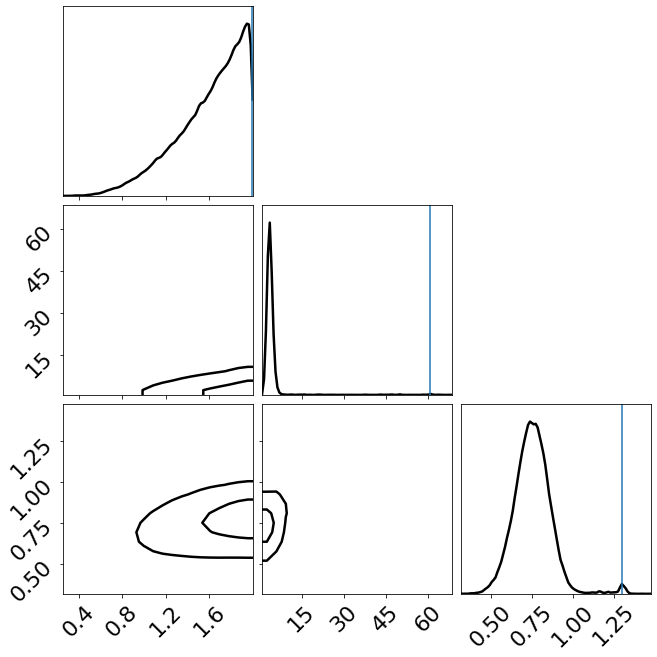

In [26]:
sys.path.append("../python/")
from _corner import corner

smooth=1.
fig, axes = corner(np.array([samples[:, 0], samples[:, 2], samples[:, 1]]).T, 
                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth, color="k",)
# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 4, 8], np.array([samples[:, 0], samples[:, 2], samples[:, 1]])):
    kde   = st.gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim()
    xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="k", lw=2.5)
    print(axidx)

import scipy.stats as st
mode = st.mode(samples)[0][0]
fig.axes[0].axvline(mode[0]); fig.axes[4].axvline(mode[2]); fig.axes[8].axvline(mode[1])

# Third step: Investigate statistics

In [31]:
import numpy as np

def HDI_from_MCMC(posterior_samples, credible_mass):
    # Computes highest density interval from a sample of representative values,
    # estimated as the shortest credible interval
    # Takes Arguments posterior_samples (samples from posterior) and credible mass (normally .95)
    sorted_points = sorted(posterior_samples)
    ciIdxInc = np.ceil(credible_mass * len(sorted_points)).astype('int')
    nCIs = len(sorted_points) - ciIdxInc
    ciWidth = [0]*nCIs
    for i in range(0, nCIs):
        ciWidth[i] = sorted_points[i + ciIdxInc] - sorted_points[i]
    HDImin = sorted_points[ciWidth.index(min(ciWidth))]
    HDImax = sorted_points[ciWidth.index(min(ciWidth))+ciIdxInc]
    return(HDImin, HDImax)

HDI_from_MCMC(samples, 0.95)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

Text(0, 0.5, 'FSE$_{\\gamma}$')

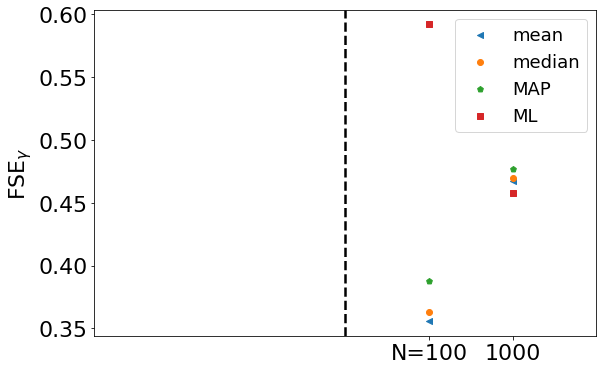

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(9, 6))

#x_axis = [1, 2, 4, 5]
x_axis = [4, 5]
ax.set_xlim(0, 6)

ax.scatter(x_axis, FSE_mean, label="mean", marker="<")
ax.scatter(x_axis, FSE_median, label="median", marker="o")
ax.scatter(x_axis, FSE_MAP, label="MAP", marker="p")
ax.scatter(x_axis, FSE_ML, label="ML", marker="s")
ax.legend(fontsize=18); ax.axvline(3, color="black", ls="--", lw=2.5)
#ax.set_xticks(x_axis); ax.set_xticklabels(["N=100", "1000", "100", "1000"])
ax.set_xticks(x_axis); ax.set_xticklabels(["N=100", "1000"])

#ax.text(0.5, 0.2, "no Tcut"); ax.text(3.5, 0.2, "Tcut>650 K")

ax.set_ylabel(r"FSE$_{\gamma}$")

**FSE with multinest**

In [10]:
filepath = "/home/mariacst/exoplanets/debug/multinest/out/v7/" 
nBDs=100; j=1
for i in [101]:#, 105]:#, 106, 111, 112]:
    file_name  = (filepath + "%i/"%(i) +                                
                     ("T650_multinest_N%i_gamma1.2_rs10.0_v%ipost_equal_weights.dat"
                     %(nBDs, i)))                                           
    samples    = np.genfromtxt(file_name, unpack=True)[0:3].T 

    counts, bins = np.histogramdd(samples, bins=10)                         
    maxval       = np.amax(counts)                                          
    pos          = np.where(counts==maxval)                                 
                                                                            
    counts[pos] = [-1]                                                      
    _maxval      = np.amax(counts)                                          
    print()                                                                 
    print(i, maxval/np.sum(counts), int(np.sum(counts)), maxval - np.sqrt(maxval)>_maxval)
    print(bins[0][pos[0]][0], bins[0][pos[0]+1][0], " - ", bins[j][pos[j]][0], bins[j][pos[j]+1][0])
    print((bins[0][pos[0]]+bins[0][pos[0]+1])/2., (bins[j][pos[j]]+bins[j][pos[j]+1])/2., (bins[2][pos[2]]+bins[2][pos[2]+1])/2.)


101 0.025418243377813184 40168 False
1.6045240898132325 1.80226180768013  -  1.0226044155162968 1.2266093588666527
[1.70339295] [1.12460689] [10.81033648]


In [13]:
filepath = "/home/mariacst/exoplanets/debug/multinest/out/v7/" 
nBDs=100; j=1
for i in [101]:#, 105]:#, 106, 111, 112]:
    file_name  = (filepath + "%i/"%(i) +                                
                     ("T650_multinest_N%i_gamma1.2_rs10.0_v%ipost_equal_weights.dat"
                     %(nBDs, i)))                                           
    samples    = np.genfromtxt(file_name, unpack=True)[0:3].T 

    counts, bins = np.histogramdd(samples, bins=9)                         
    maxval       = np.amax(counts)                                          
    pos          = np.where(counts==maxval)                                 
                                                                            
    counts[pos] = [-1]                                                      
    _maxval      = np.amax(counts)                                          
    print()                                                                 
    print(i, maxval/np.sum(counts), int(np.sum(counts)), maxval - np.sqrt(maxval)>_maxval)
    print(bins[0][pos[0]][0], bins[0][pos[0]+1][0], " - ", bins[j][pos[j]][0], bins[j][pos[j]+1][0])
    print((bins[0][pos[0]]+bins[0][pos[0]+1])/2., (bins[j][pos[j]]+bins[j][pos[j]+1])/2., (bins[2][pos[2]]+bins[2][pos[2]+1])/2.)


101 0.02833674539371848 40054 False
1.7802909501393636 1.9999995255470275  -  1.1359404951553833 1.3626126544335562
[1.89014524] [1.24927657] [19.70771987]


v4
N=100   [101 105 111 112 114 117 120 124 128 129 131 132 133 134 135 136 141 145
 150 151 153 155 157 161 162 164 166 170 172 173 176 178 179 182 183 184
 186 190 194 197 200]
v0


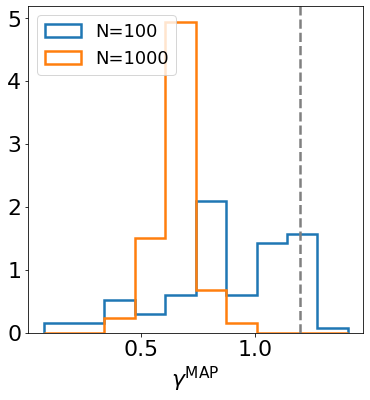

In [7]:
path = "/home/mariacst/exoplanets/results/"
true = 1.2
FSE  = []
N    = [100, 1000]
v    = ["v4", "v0"]
rank = 100.
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
i=0
for nBDs in N:
    mode = np.genfromtxt(path + "statistics_multinest_N%i_sigma0.1_gamma1.2rs10.0_"%nBDs + v[i], unpack=True)[1]
    print(v[i])
    i+=1
    if nBDs<200:
        counts, bins, _ = ax.hist(mode, histtype="step", lw=2.5, density=True, label="N=%i"%nBDs);
        pos = np.where(mode>1)
        print("N=100  ", pos[0]+101)
    else:
        ax.hist(mode, bins=bins, histtype="step", lw=2.5, density=True, label="N=%i"%nBDs);
    FSE.append(np.sqrt(1/rank*np.sum(np.power(mode - true, 2)))/true)
ax.set_xlabel(r"$\gamma^{\rm MAP}$"); ax.legend(fontsize=18)
ax.axvline(true, color="grey", lw=2.5, ls="--")

In [4]:
print(FSE)

[0.348724625420976, 0.4568998657923978]


In [8]:
def return_ML(filepath):
    ML = []
    with open(filepath) as f:
        for val in f.readlines():
            #print(val)
            val = val.replace("\n","")
            val = val.split('   ')
            ML = [float(val[7]), float(val[8]), float(val[9])]
            break
    return ML

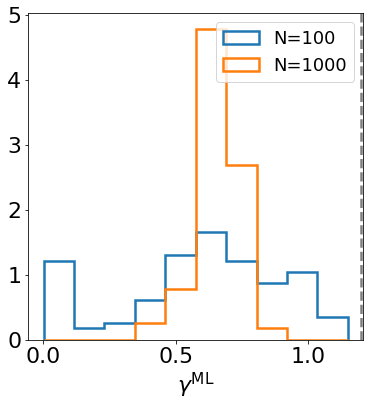

In [10]:
path   = ["/home/mariacst/exoplanets/debug/multinest/out/",
         "/home/mariacst/exoplanets/debug/multinest/out/v0/"]
#path   = "/hdfs/local/mariacst/exoplanets/results/multinest/onlySigmaT/sampling_efficiency_1/"
rank   = 100
true   = 1.2
N      = [100, 1000]
ML     = []
FSE_ML = []
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
for k in range(len(N)):
    ML.append([])
    for i in range(rank):
        ML[k].append(return_ML(path[k] + "%i/T650_multinest_N%i_gamma1.2_rs10.0_v%isummary.txt"%(i+101, N[k], i+101))) 
    ML[k] = np.array(ML[k])
    
    if N[k]<200:
        counts, bins, _ = ax.hist(ML[k][:, 1], histtype="step", lw=2.5, label="N=%i"%N[k], density=True);
    else:
        ax.hist(ML[k][:, 1], histtype="step", bins=bins, lw=2.5, label="N=%i"%N[k], density=True)
    #print(ML[k][:, 1])
    FSE_ML.append(np.sqrt(1/rank*np.sum(np.power(ML[k][:, 1] - true, 2)))/true)

ax.set_xlabel(r"$\gamma^{\rm ML}$"); ax.legend(fontsize=18)
ax.axvline(true, color="grey", lw=2.5, ls="--")

In [11]:
FSE_ML

[0.5662996071232717, 0.46059429163690213]

**Some plotting**

In [14]:
filepath = "/home/mariacst/exoplanets/debug/multinest/out/v7/101/"
_file    = filepath + "T650_multinest_N100_gamma1.2_rs10.0_v101post_equal_weights.dat"
samples  = np.genfromtxt(_file, unpack=True)

Text(0.5, 0, '$\\gamma$')

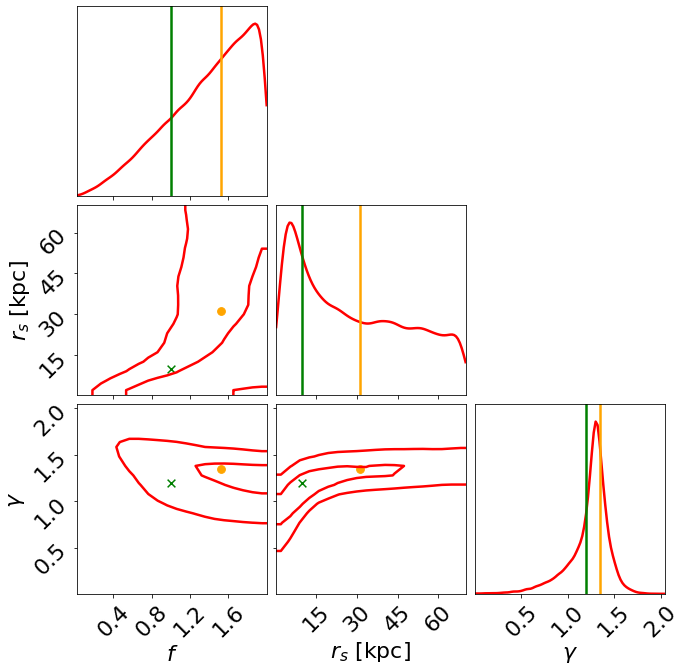

In [15]:
smooth=1.

gamma=1.2; rs=10.; f=1.

fig, axes = corner(np.array([samples[0], samples[2], samples[1]]).T, 
                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth, color="red",)
# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 4, 8], np.array([samples[0], samples[2], samples[1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="red", lw=2.5)   
    
axes[0, 0].axvline(1., color="g", ls="-", lw=2.5); axes[1, 1].axvline(rs, color="g", ls="-", lw=2.5); 
axes[2, 2].axvline(gamma, color="g", ls="-", lw=2.5); axes[1, 0].scatter(f, rs, marker="x", color="g", s=60); 
axes[2, 0].scatter(f, gamma, marker="x", color="g", s=60); axes[2, 1].scatter(rs, gamma, marker="x", color="g", s=60);

#gamma=0.128967135512679437E+00; f=0.102326114434090987E+01; rs=0.570431942228791797E+02
#axes[0, 0].axvline(f, color="k", ls="-", lw=2.5); axes[1, 1].axvline(rs, color="k", ls="-", lw=2.5); 
#axes[2, 2].axvline(gamma, color="k", ls="-", lw=2.5); axes[1, 0].scatter(f, rs, marker="o", color="k", s=60); 
#axes[2, 0].scatter(f, gamma, marker="o", color="k", s=60); 
#axes[2, 1].scatter(rs, gamma, marker="o", color="k", s=60);

gamma=0.134733509563189058E+01; f=0.152227412837361409E+01; rs=0.313440322561544633E+02
axes[0, 0].axvline(f, color="orange", ls="-", lw=2.5); 
axes[1, 1].axvline(rs, color="orange", ls="-", lw=2.5); 
axes[2, 2].axvline(gamma, color="orange", ls="-", lw=2.5); 
axes[1, 0].scatter(f, rs, marker="o", color="orange", s=60); 
axes[2, 0].scatter(f, gamma, marker="o", color="orange", s=60); 
axes[2, 1].scatter(rs, gamma, marker="o", color="orange", s=60);


axes[1, 0].set_ylabel(r"$r_s$ [kpc]"); axes[2, 0].set_xlabel(r"$f$"); axes[2, 0].set_ylabel(r"$\gamma$")
axes[2, 1].set_xlabel(r"$r_s$ [kpc]"); axes[2, 2].set_xlabel(r"$\gamma$")

In [23]:
# Calculate HPD credible interval of 95%
import arviz as az
az.hdi(samples, hdi_prob=0.95)

array([[1.98042068, 1.98085967],
       [1.31383812, 1.31438661],
       [2.4489485 , 2.45228471]])

### Finding mode in full/joint pdf

In [ ]:
counts, bins = np.histogramdd(samples, bins=3000) #bins=(10, 9, 8))

In [10]:
print(counts.shape)
print(counts[0].shape, counts[:, 0].shape, counts[:, :, 0].shape)
print(bins[0].shape, bins[1].shape, bins[2].shape)
print(np.min(bins[0]), np.max(bins[0]))
print(np.min(bins[1]), np.max(bins[1]))
print(np.min(bins[2]), np.max(bins[2]))

(10, 9, 8)
(9, 8) (10, 8) (10, 9)
(11,) (10,) (9,)
0.07816910490973113 1.999997011840602
0.00017496247573306478 1.9732196998838365
0.41656612304080465 69.98698146801804


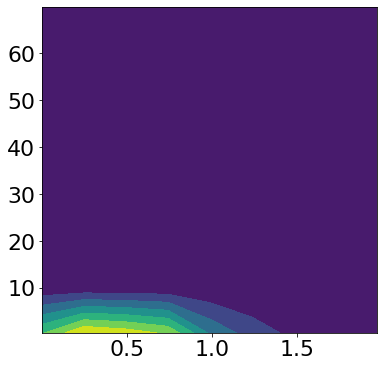

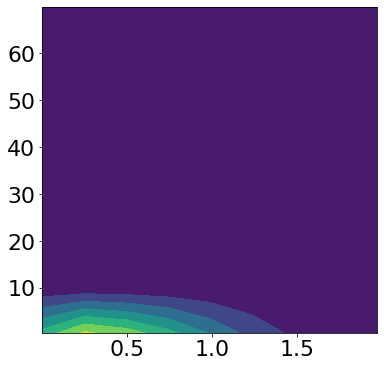

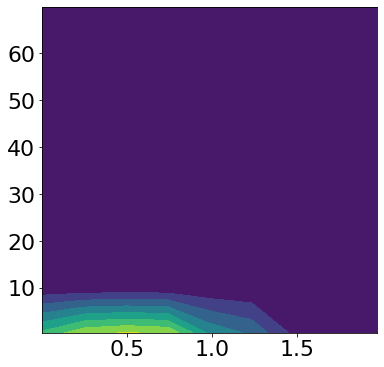

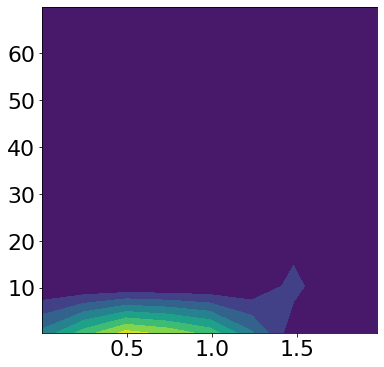

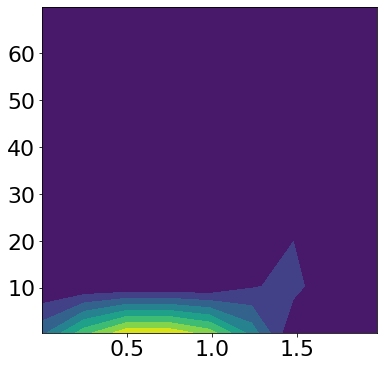

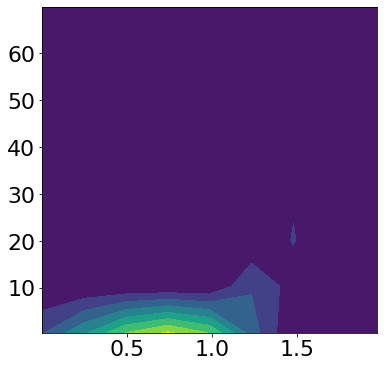

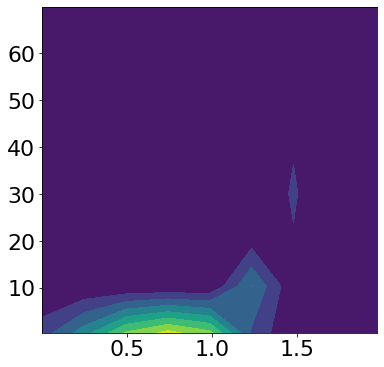

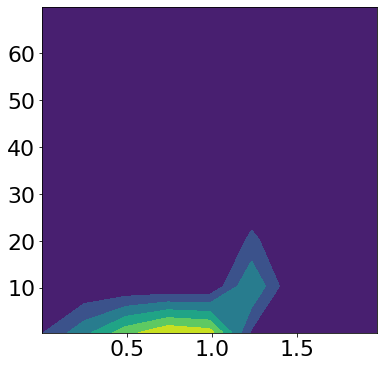

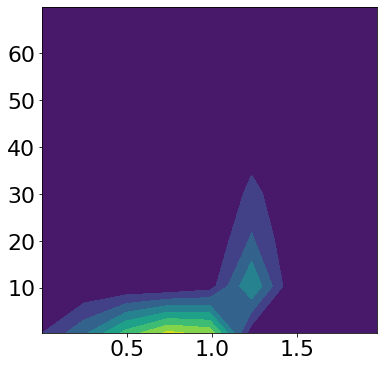

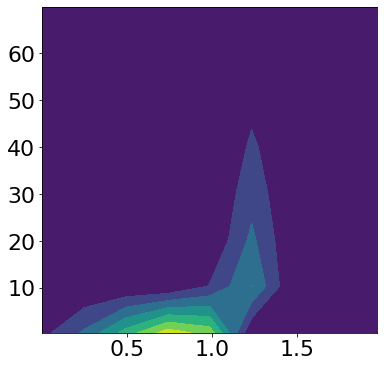

In [31]:
import matplotlib.cm as cm

#ax.imshow(counts[0], interpolation="bilinear", cmap=cm.viridis)#,
          #extent=(np.min(bins[1]), np.max(bins[1]), np.min(bins[2]), np.max(bins[2])))
    
    
x = np.linspace(np.min(bins[0]), np.max(bins[0]), len(bins[0])-1) # f
y = np.linspace(np.min(bins[1]), np.max(bins[1]), len(bins[1])-1) # gamma
z = np.linspace(np.min(bins[2]), np.max(bins[2]), len(bins[2])-1) # rs

[Y, Z] = np.meshgrid(y, z)
for i in range(len(bins[0])-1):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.contourf(Y, Z, counts[i].T)

In [34]:
print(bins[1])

[1.74962476e-04 2.19402156e-01 4.38629349e-01 6.57856542e-01
 8.77083735e-01 1.09631093e+00 1.31553812e+00 1.53476531e+00
 1.75399251e+00 1.97321970e+00]


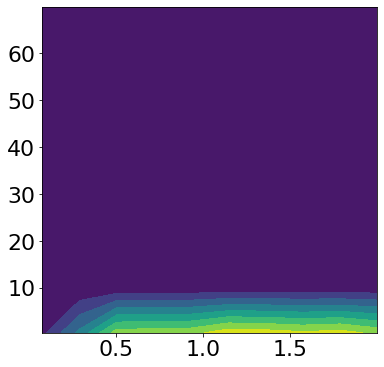

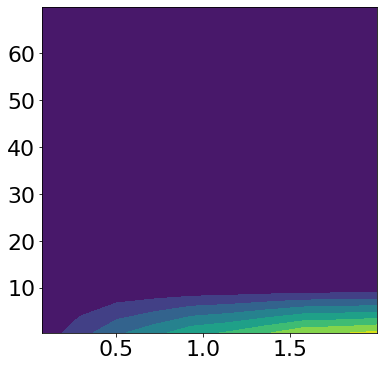

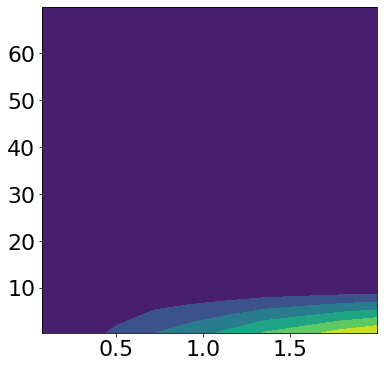

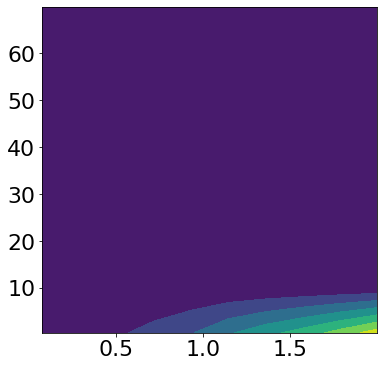

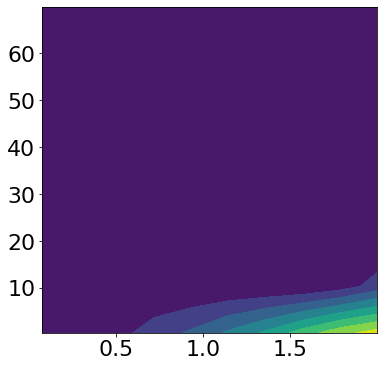

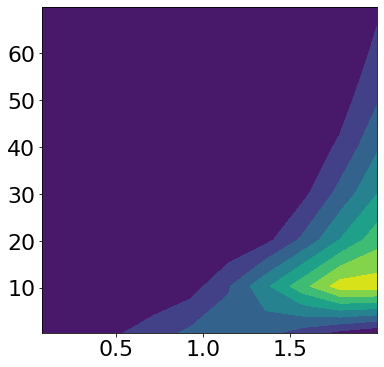

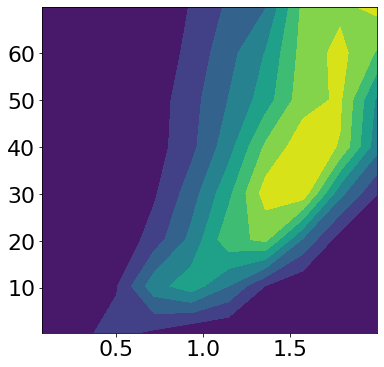

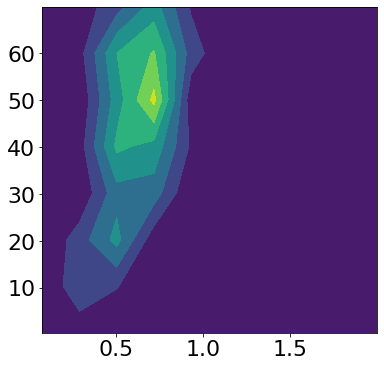

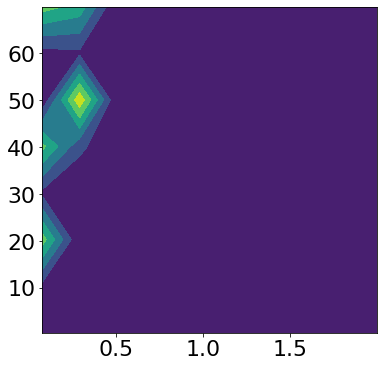

In [33]:
[X, Z] = np.meshgrid(x, z)
for i in range(len(bins[1])-1):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.contourf(X, Z, counts[:, i].T)

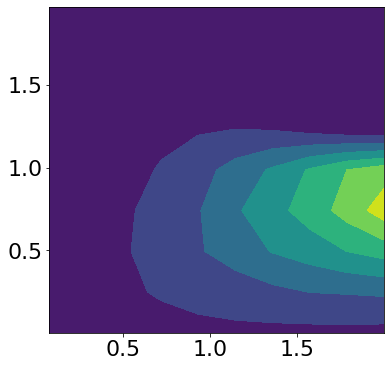

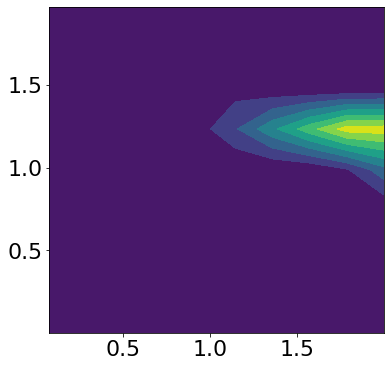

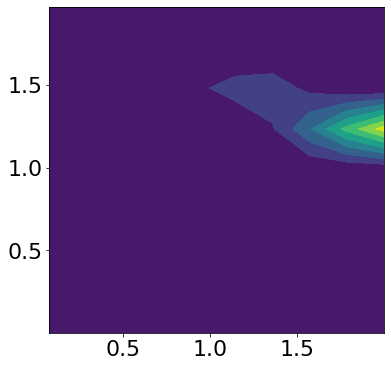

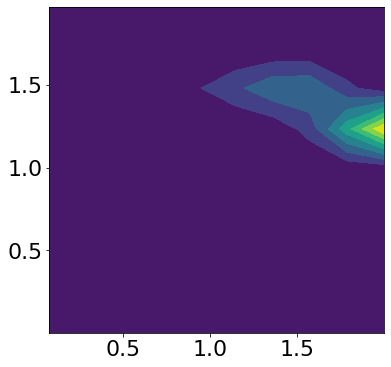

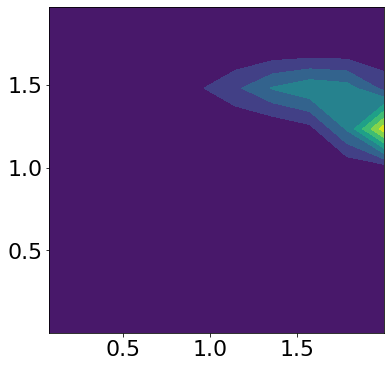

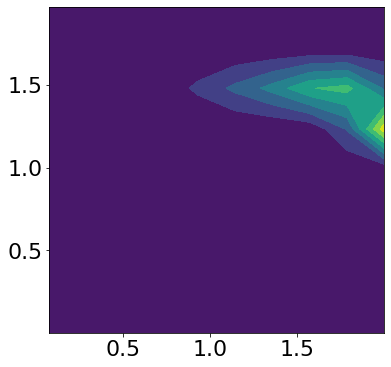

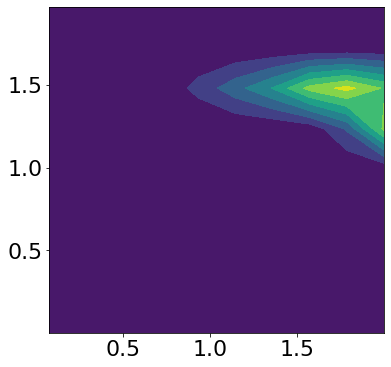

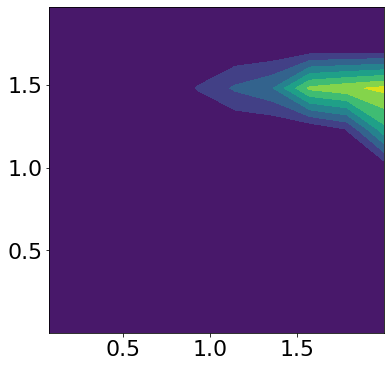

In [35]:
[X, Y] = np.meshgrid(x, y)
for i in range(len(bins[2])-1):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.contourf(X, Y, counts[:, :, i].T)

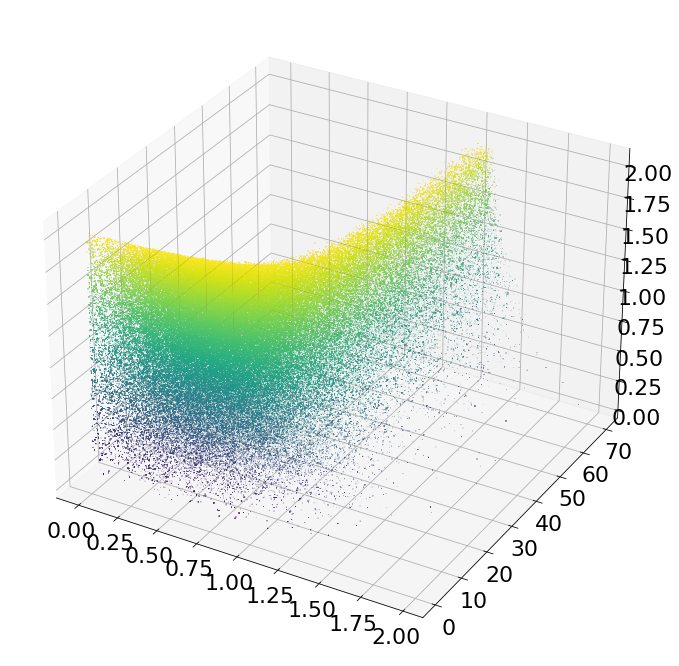

In [36]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 12))

ax = fig.add_subplot(111, projection='3d')

#plot_ = ax.scatter3D(data[1], data[2], data[0], s=0.1)
ax.scatter(samples[:, 1], samples[:, 2], samples[:, 0],  c=samples[:, 0], cmap='viridis', linewidth=0.5, s=0.001)

plt.show()

In [ ]:
maxval = np.amax(counts)
pos = np.where(counts==maxval)

In [139]:
print((bins[0][pos[0]]+bins[0][pos[0]+1])/2.) # bins=2000
print((bins[1][pos[1]]+bins[1][pos[1]+1])/2.)
print((bins[2][pos[2]]+bins[2][pos[2]+1])/2.)

[1.90919064]
[1.11938459]
[12.78270745]


In [133]:
print((bins[0][pos[0]]+bins[0][pos[0]+1])/2.) # bins=1000
print((bins[1][pos[1]]+bins[1][pos[1]+1])/2.)
print((bins[2][pos[2]]+bins[2][pos[2]+1])/2.)

[1.90871019]
[1.11987785]
[12.76531485]


In [128]:
print((bins[0][pos[0]]+bins[0][pos[0]+1])/2.) 
print((bins[1][pos[1]]+bins[1][pos[1]+1])/2.)
print((bins[2][pos[2]]+bins[2][pos[2]+1])/2.)

[1.97116959]
[0.66114495]
[3.54723481]


In [88]:
nBDs = 100 ; sigma = 0.2
f = 1.; gamma = 1.2; rs = 10.

rank = 101
filepath = "/hdfs/local/mariacst/exoplanets/results/onlySigmaT/posterior/N100/"
_file    = open(filepath + ("posterior_Tcut_onlySigmaT_N%i_sigma0.1_gamma1.2rs10.0_nwalkers300_steps9000_v%i" 
                            %(nBDs, rank)), "rb") 
samples  = pickle.load(_file)

counts, bins = np.histogramdd(samples, bins=(60, 150, 60))

In [93]:
maxval = np.amax(counts)
pos = np.where(counts==maxval)
print(maxval)

print((bins[0][pos[0]]+bins[0][pos[0]+1])/2.) # N = 500
print((bins[1][pos[1]]+bins[1][pos[1]+1])/2.)
print((bins[2][pos[2]]+bins[2][pos[2]+1])/2.)

1158.0
[0.31651738]
[0.33626634]
[1.0027727]


In [90]:
pos = np.where((1.82 < samples[:, 0]) & (samples[:, 0] < 1.89) & 
               (0.97 < samples[:, 1]) & (samples[:, 1] < 1.08) & 
               (9.1 < samples[:, 2]) & (samples[:, 2] < 9.7))
len(pos[0])

2631

In [99]:
print(bins[0])
_ = bins[0][54]

pos = np.where((bins[0][54] < samples[:, 0]) & (samples[:, 0] < bins[0][55]) & 
               (0.97 < samples[:, 1]) & (samples[:, 1] < 1.08) & 
               (9.1 < samples[:, 2]) & (samples[:, 2] < 9.7))
len(pos[0])

[0.03866293 0.07135169 0.10404045 0.13672921 0.16941797 0.20210673
 0.23479549 0.26748425 0.300173   0.33286176 0.36555052 0.39823928
 0.43092804 0.4636168  0.49630556 0.52899432 0.56168308 0.59437183
 0.62706059 0.65974935 0.69243811 0.72512687 0.75781563 0.79050439
 0.82319315 0.85588191 0.88857067 0.92125942 0.95394818 0.98663694
 1.0193257  1.05201446 1.08470322 1.11739198 1.15008074 1.1827695
 1.21545825 1.24814701 1.28083577 1.31352453 1.34621329 1.37890205
 1.41159081 1.44427957 1.47696833 1.50965709 1.54234584 1.5750346
 1.60772336 1.64041212 1.67310088 1.70578964 1.7384784  1.77116716
 1.80385592 1.83654467 1.86923343 1.90192219 1.93461095 1.96729971
 1.99998847]


820

In [84]:
counts[pos] = -1

In [85]:
maxval = np.amax(counts)
pos = np.where(counts==maxval)

print((bins[0][pos[0]]+bins[0][pos[0]+1])/2.) # N = 500
print((bins[1][pos[1]]+bins[1][pos[1]+1])/2.)
print((bins[2][pos[2]]+bins[2][pos[2]+1])/2.)

[1.36255767]
[1.05867628]
[6.80082378]


In [86]:
maxval

880.0

In [72]:
maxval = np.amax(counts)
pos = np.where(counts==maxval)

print((bins[0][pos[0]]+bins[0][pos[0]+1])/2.) # N = 500
print((bins[1][pos[1]]+bins[1][pos[1]+1])/2.)
print((bins[2][pos[2]]+bins[2][pos[2]+1])/2.)

[1.86269568]
[1.04163831]
[9.46792728]


In [73]:
pos

(array([46]), array([49]), array([6]))

In [57]:
counts[pos]

array([1158.])

In [63]:
samples[:, 0]

array([1.6861021 , 1.73687471, 1.72188076, ..., 1.83684317, 1.31835903,
       1.52466948])

In [70]:
pos = np.where((0.32 < samples[:, 0]) & (samples[:, 0] < 0.33) & 
               (0.33 < samples[:, 1]) & (samples[:, 1] < 0.34) & 
               (0.84 < samples[:, 2]) & (samples[:, 2] < 0.98))
len(pos[0])

1158

In [87]:
pos = np.where((1.82 < samples[:, 0]) & (samples[:, 0] < 1.89) & 
               (0.97 < samples[:, 1]) & (samples[:, 1] < 1.08) & 
               (9.1 < samples[:, 2]) & (samples[:, 2] < 9.7))
len(pos[0])

2631

In [51]:
maxval = np.amax(counts)
pos = np.where(counts==maxval)

print((bins[0][pos[0]]+bins[0][pos[0]+1])/2.) # N = (50, 100, 50)
print((bins[1][pos[1]]+bins[1][pos[1]+1])/2.)
print((bins[2][pos[2]]+bins[2][pos[2]+1])/2.)

[1.78424266]
[1.03141553]
[7.72851196]


In [46]:
maxval = np.amax(counts)
pos = np.where(counts==maxval)

print((bins[0][pos[0]]+bins[0][pos[0]+1])/2.) # N = (50, 100, 50)
print((bins[1][pos[1]]+bins[1][pos[1]+1])/2.)
print((bins[2][pos[2]]+bins[2][pos[2]+1])/2.)

[1.86269568]
[1.04163831]
[9.46792728]


In [13]:
maxval = np.amax(counts)
pos = np.where(counts==maxval)

print((bins[0][pos[0]]+bins[0][pos[0]+1])/2.) # N=1000
print((bins[1][pos[1]]+bins[1][pos[1]+1])/2.)
print((bins[2][pos[2]]+bins[2][pos[2]+1])/2.)

[0.3240358]
[0.33319951]
[0.87521558]


In [15]:
print(maxval, pos)

1158.0 (array([145]), array([148]), array([6]))


In [16]:
bins[0][130:150]

array([0.29363525, 0.29559658, 0.2975579 , 0.29951923, 0.30148055,
       0.30344188, 0.30540321, 0.30736453, 0.30932586, 0.31128718,
       0.31324851, 0.31520983, 0.31717116, 0.31913248, 0.32109381,
       0.32305514, 0.32501646, 0.32697779, 0.32893911, 0.33090044])

In [39]:
pos

(array([47]), array([23]), array([5]))

0.2674842450643433


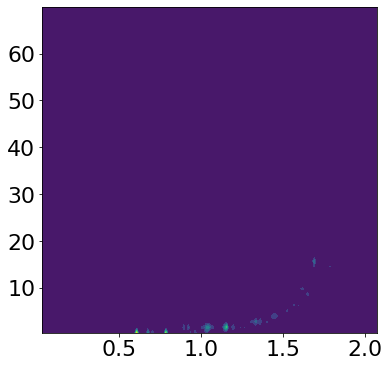

In [102]:
import matplotlib.cm as cm

#ax.imshow(counts[0], interpolation="bilinear", cmap=cm.viridis)#,
          #extent=(np.min(bins[1]), np.max(bins[1]), np.min(bins[2]), np.max(bins[2])))
    
    
x = np.linspace(np.min(bins[0]), np.max(bins[0]), len(bins[0])-1) # f
y = np.linspace(np.min(bins[1]), np.max(bins[1]), len(bins[1])-1) # gamma
z = np.linspace(np.min(bins[2]), np.max(bins[2]), len(bins[2])-1) # rs

[Y, Z] = np.meshgrid(y, z)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
print(bins[0][7])
ax.contourf(Y, Z, counts[7].T)

1.8823089373791786


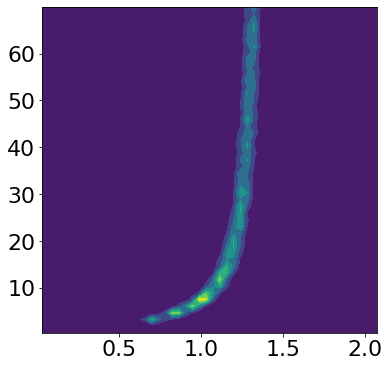

In [40]:
import matplotlib.cm as cm

#ax.imshow(counts[0], interpolation="bilinear", cmap=cm.viridis)#,
          #extent=(np.min(bins[1]), np.max(bins[1]), np.min(bins[2]), np.max(bins[2])))
    
    
x = np.linspace(np.min(bins[0]), np.max(bins[0]), len(bins[0])-1) # f
y = np.linspace(np.min(bins[1]), np.max(bins[1]), len(bins[1])-1) # gamma
z = np.linspace(np.min(bins[2]), np.max(bins[2]), len(bins[2])-1) # rs

[Y, Z] = np.meshgrid(y, z)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
print(bins[0][47])
ax.contourf(Y, Z, counts[47].T)

0.31324850759958156


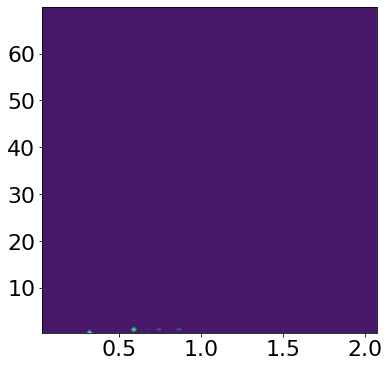

In [36]:
import matplotlib.cm as cm

#ax.imshow(counts[0], interpolation="bilinear", cmap=cm.viridis)#,
          #extent=(np.min(bins[1]), np.max(bins[1]), np.min(bins[2]), np.max(bins[2])))
    
    
x = np.linspace(np.min(bins[0]), np.max(bins[0]), len(bins[0])-1) # f
y = np.linspace(np.min(bins[1]), np.max(bins[1]), len(bins[1])-1) # gamma
z = np.linspace(np.min(bins[2]), np.max(bins[2]), len(bins[2])-1) # rs

[Y, Z] = np.meshgrid(y, z)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
print(bins[0][14])
ax.contourf(Y, Z, counts[14].T)

1.6077233621677491


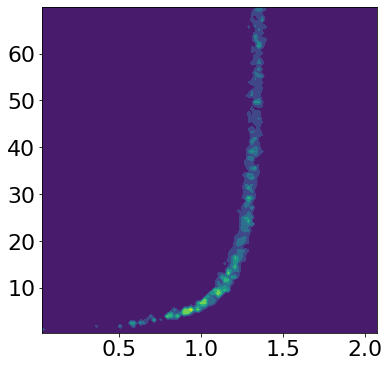

In [33]:
import matplotlib.cm as cm

#ax.imshow(counts[0], interpolation="bilinear", cmap=cm.viridis)#,
          #extent=(np.min(bins[1]), np.max(bins[1]), np.min(bins[2]), np.max(bins[2])))
    
    
x = np.linspace(np.min(bins[0]), np.max(bins[0]), len(bins[0])-1) # f
y = np.linspace(np.min(bins[1]), np.max(bins[1]), len(bins[1])-1) # gamma
z = np.linspace(np.min(bins[2]), np.max(bins[2]), len(bins[2])-1) # rs

[Y, Z] = np.meshgrid(y, z)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
print(bins[0][80])
ax.contourf(Y, Z, counts[80].T)

IndexError: index 900 is out of bounds for axis 0 with size 61

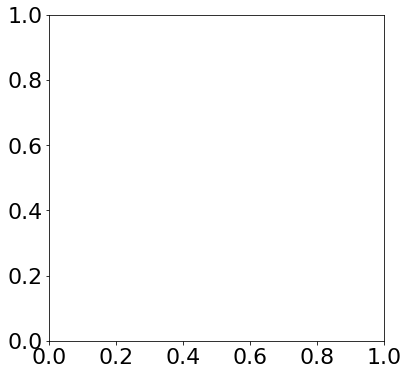

In [100]:
import matplotlib.cm as cm

#ax.imshow(counts[0], interpolation="bilinear", cmap=cm.viridis)#,
          #extent=(np.min(bins[1]), np.max(bins[1]), np.min(bins[2]), np.max(bins[2])))
    
    
x = np.linspace(np.min(bins[0]), np.max(bins[0]), len(bins[0])-1) # f
y = np.linspace(np.min(bins[1]), np.max(bins[1]), len(bins[1])-1) # gamma
z = np.linspace(np.min(bins[2]), np.max(bins[2]), len(bins[2])-1) # rs

[Y, Z] = np.meshgrid(y, z)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
print(bins[0][900])
ax.contourf(Y, Z, np.log(counts[900].T))

/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  del sys.path[0]


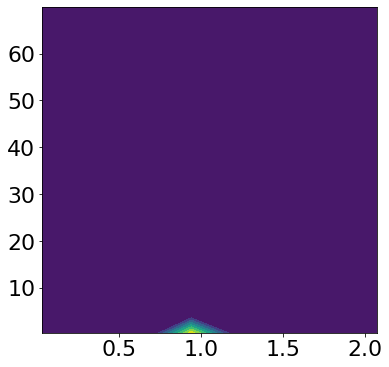

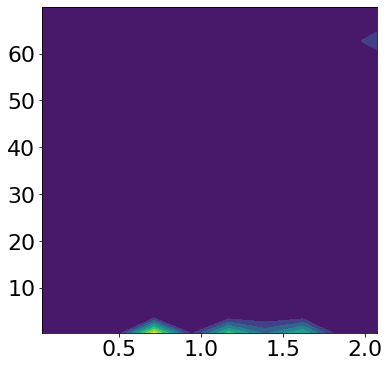

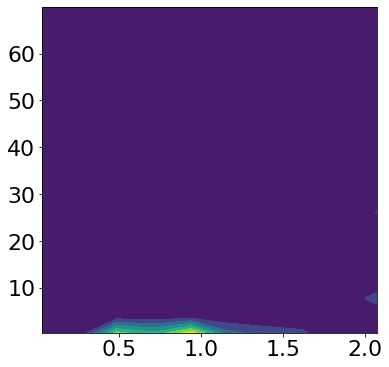

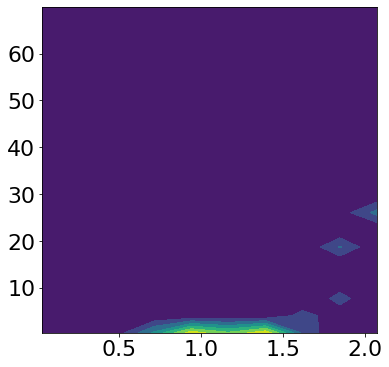

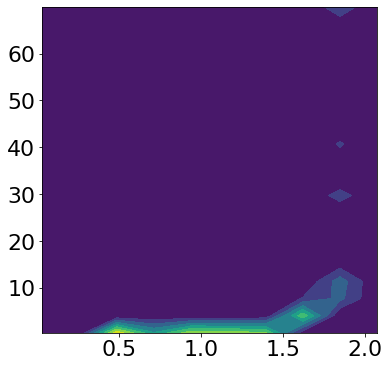

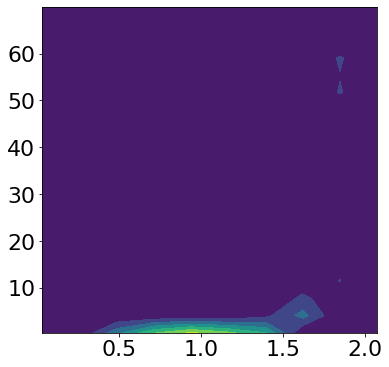

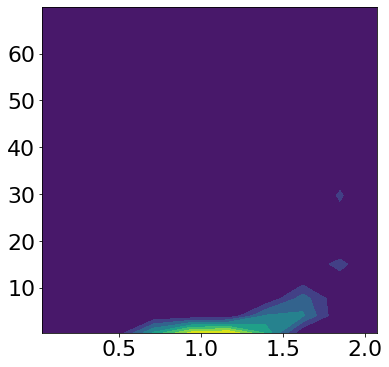

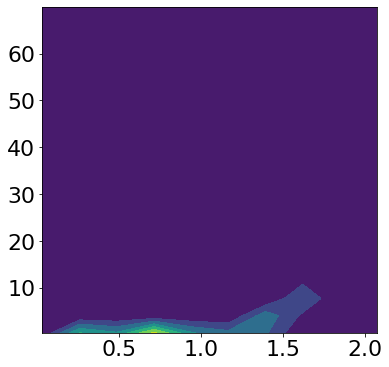

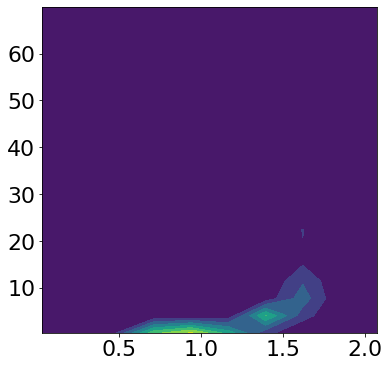

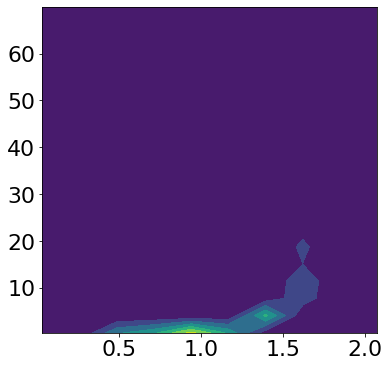

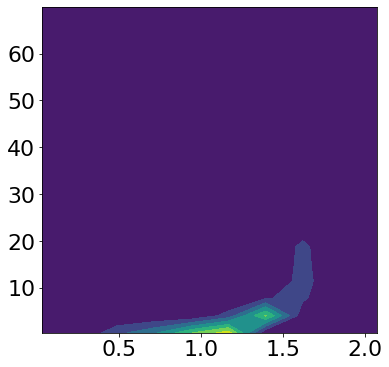

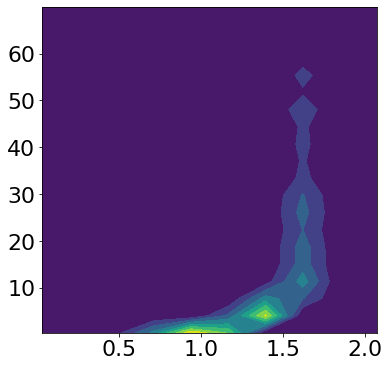

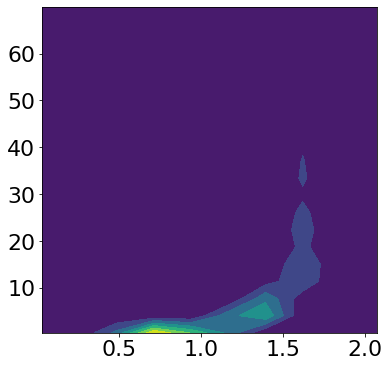

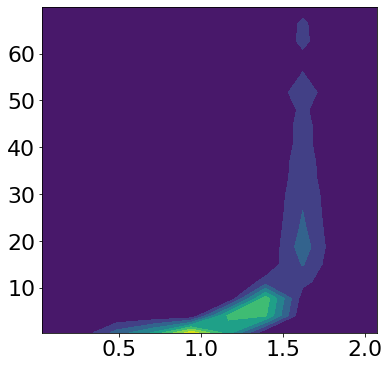

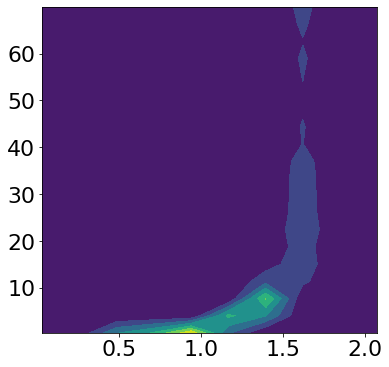

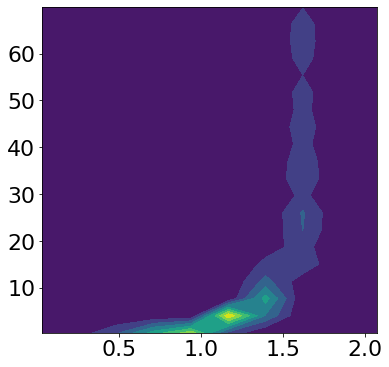

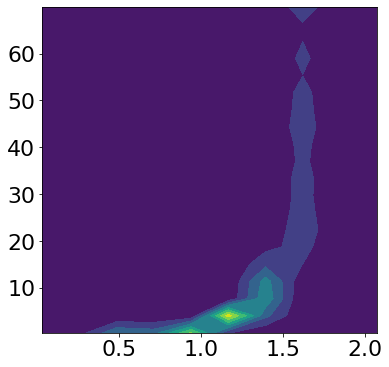

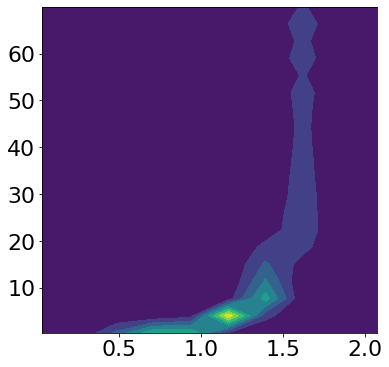

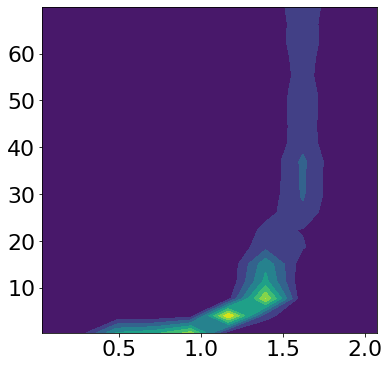

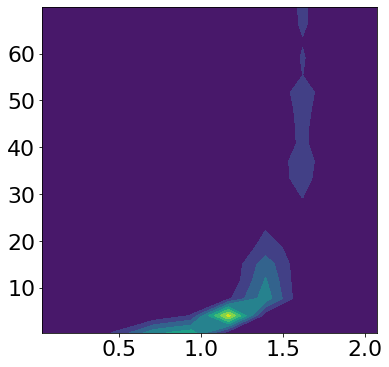

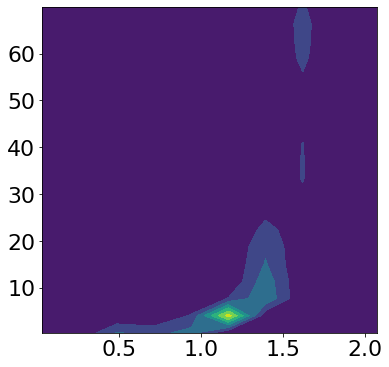

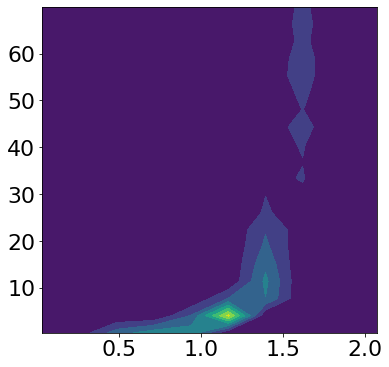

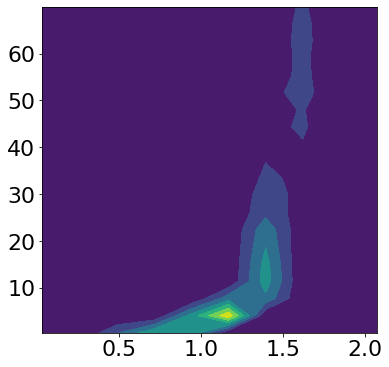

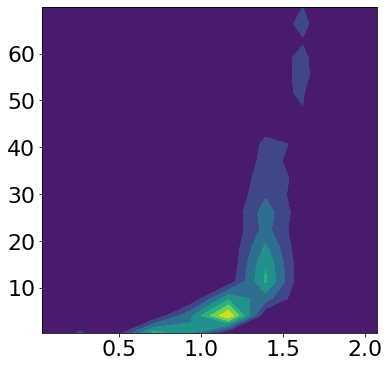

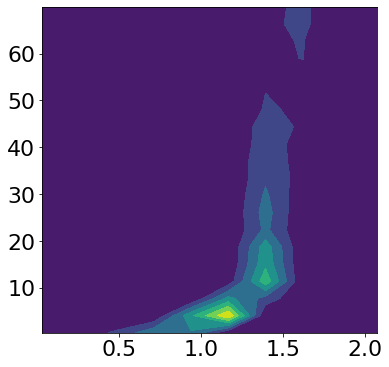

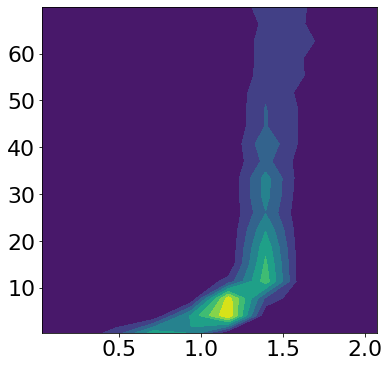

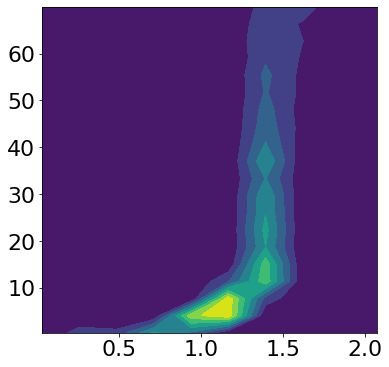

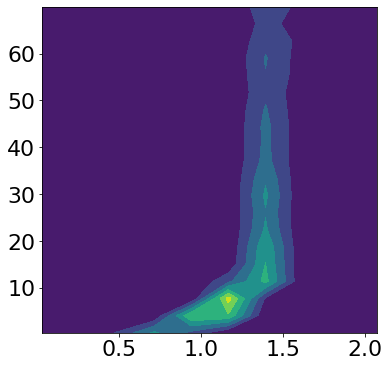

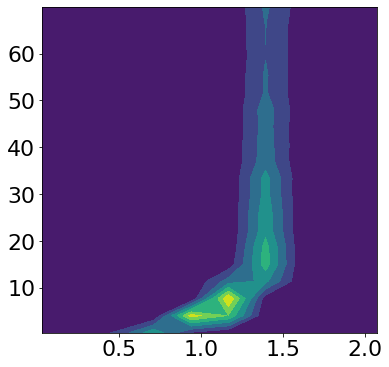

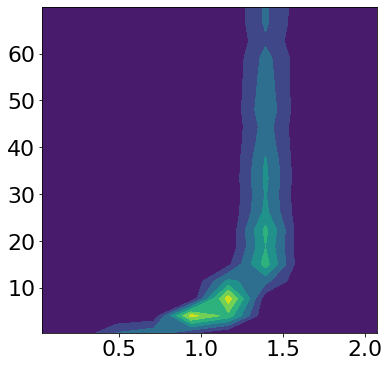

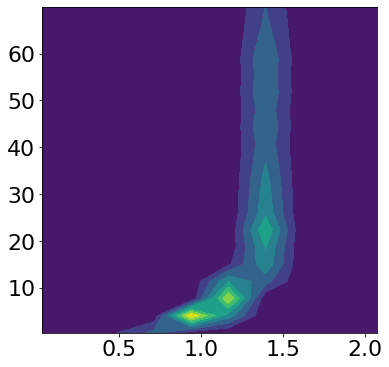

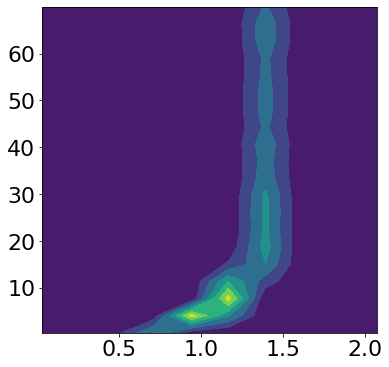

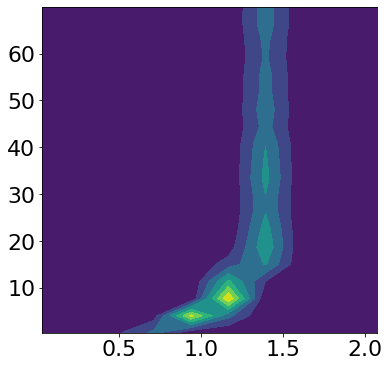

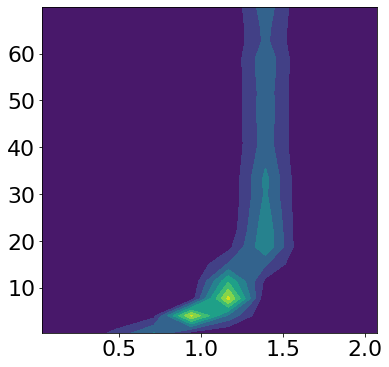

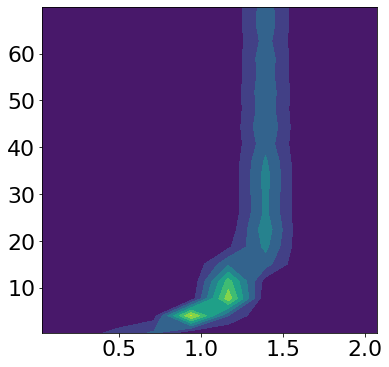

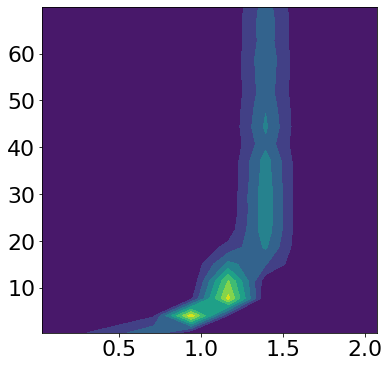

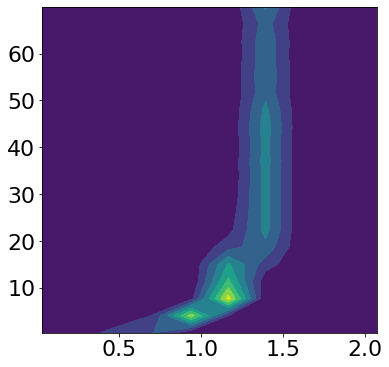

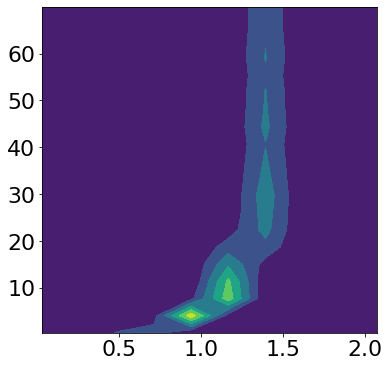

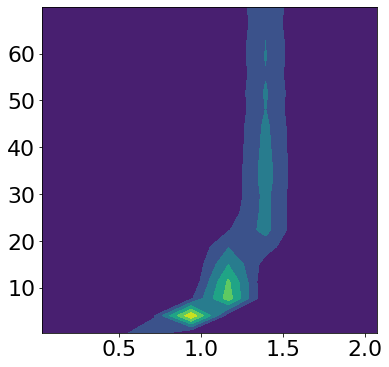

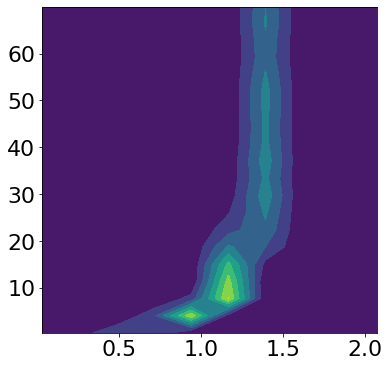

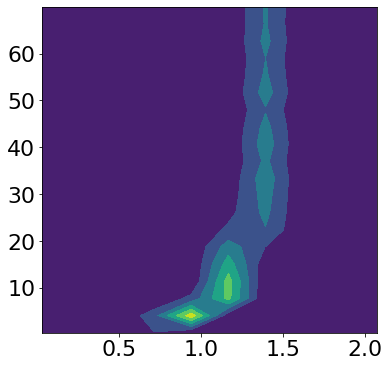

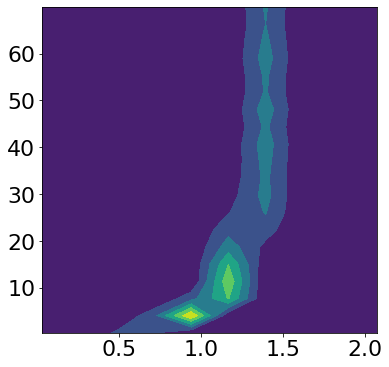

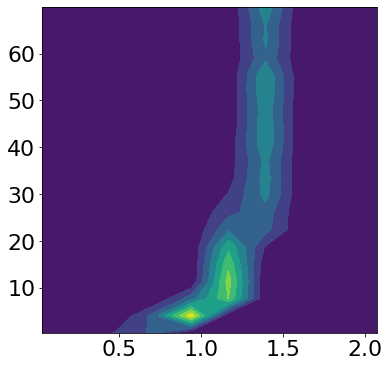

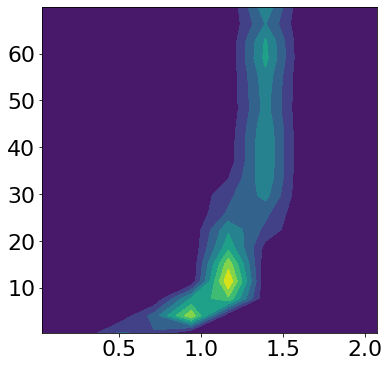

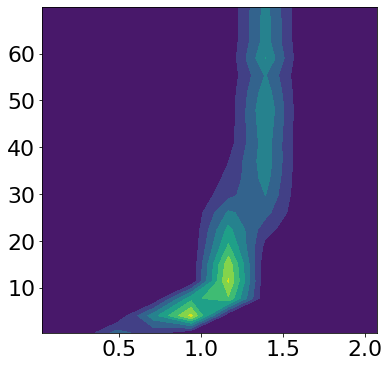

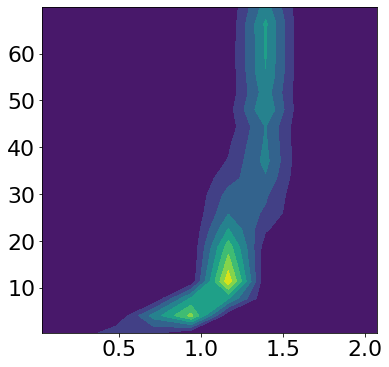

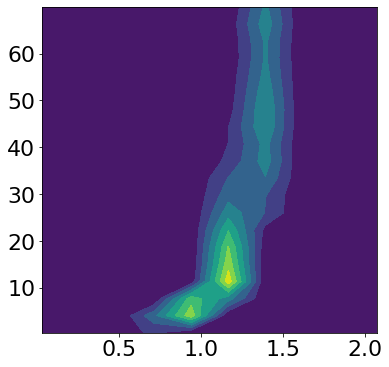

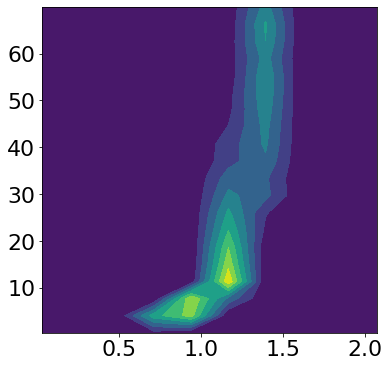

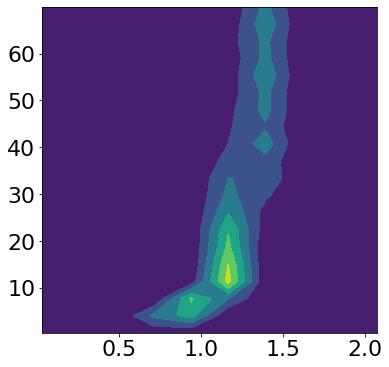

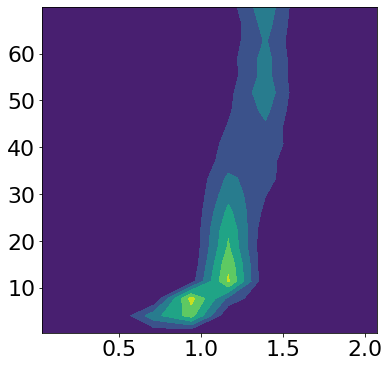

In [107]:
counts, bins = np.histogramdd(samples, bins=(50, 10, 20))

#ax.imshow(counts[0], interpolation="bilinear", cmap=cm.viridis)#,
          #extent=(np.min(bins[1]), np.max(bins[1]), np.min(bins[2]), np.max(bins[2])))
    
    
x = np.linspace(np.min(bins[0]), np.max(bins[0]), len(bins[0])-1) # f
y = np.linspace(np.min(bins[1]), np.max(bins[1]), len(bins[1])-1) # gamma
z = np.linspace(np.min(bins[2]), np.max(bins[2]), len(bins[2])-1) # rs

[Y, Z] = np.meshgrid(y, z)
for i in range(len(bins[0])-1):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.contourf(Y, Z, counts[i].T)

/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  del sys.path[0]


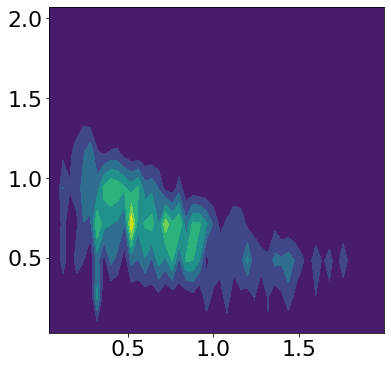

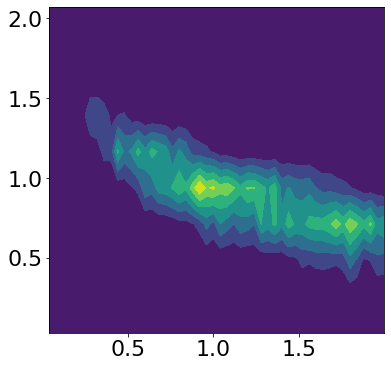

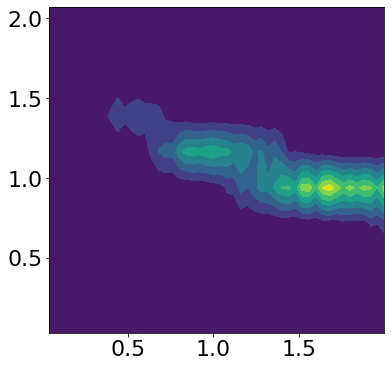

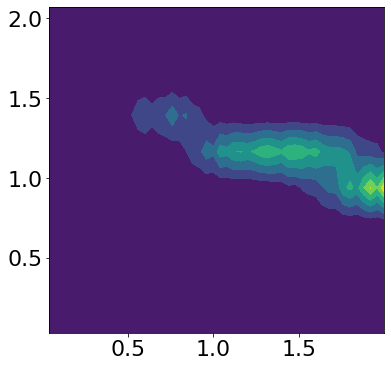

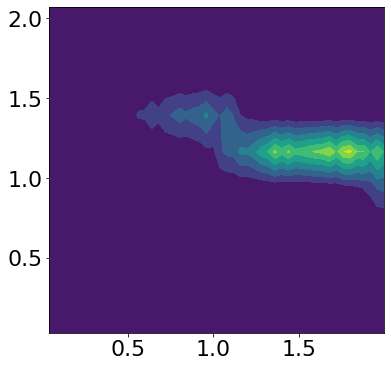

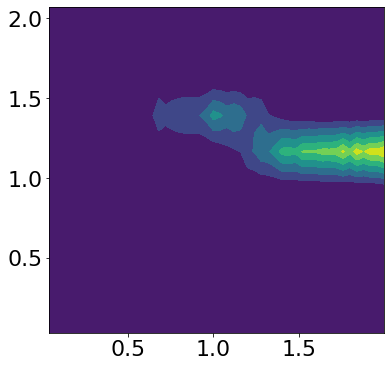

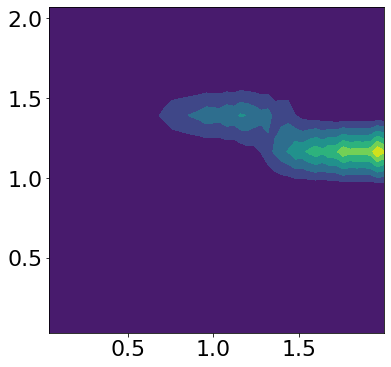

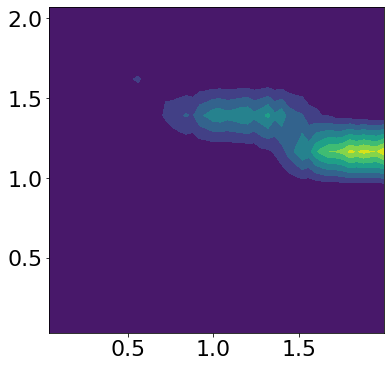

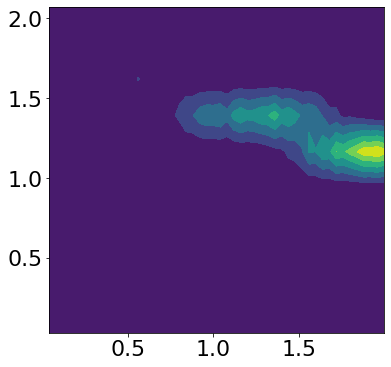

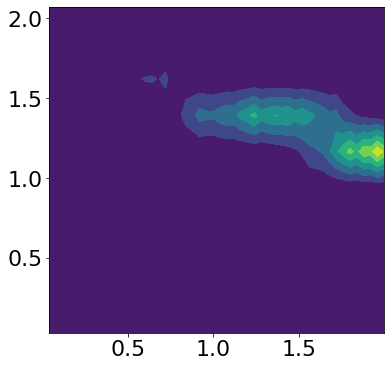

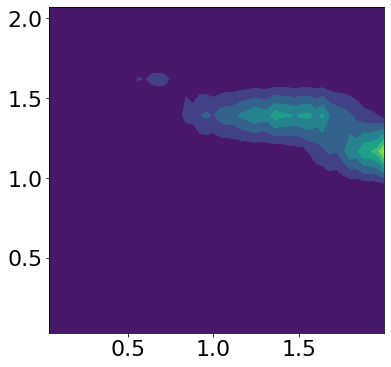

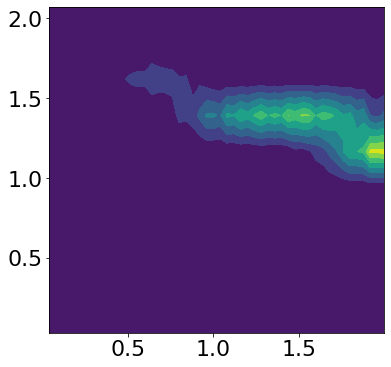

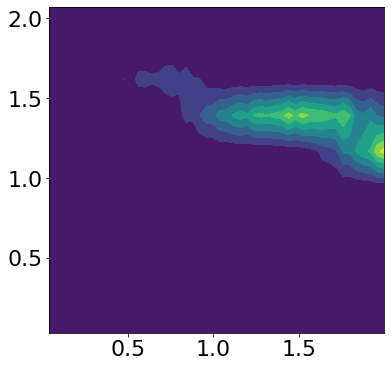

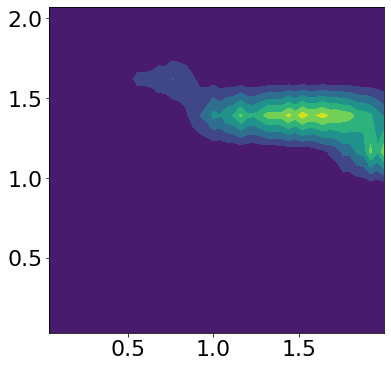

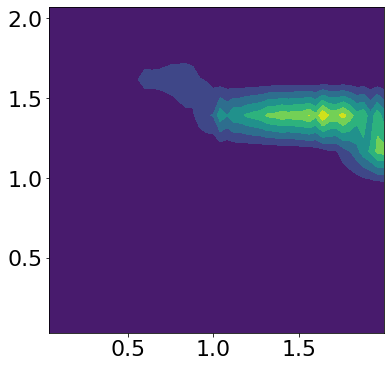

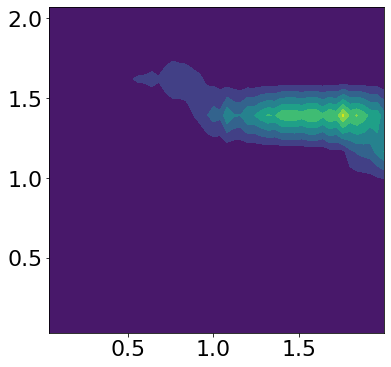

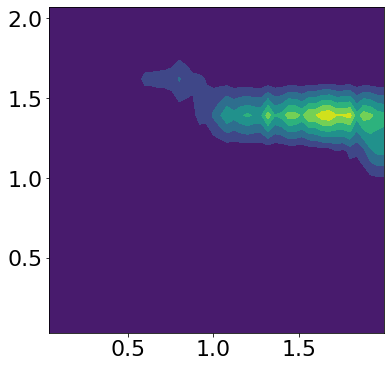

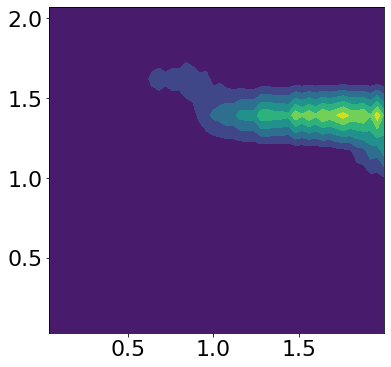

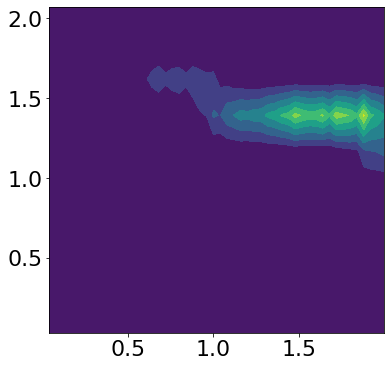

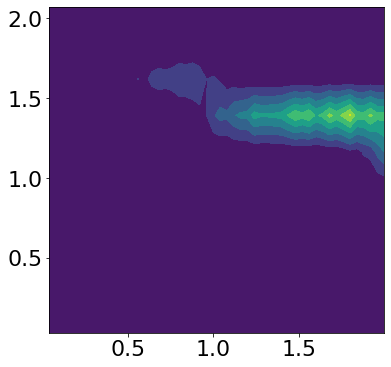

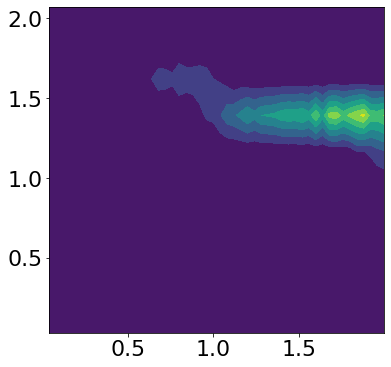

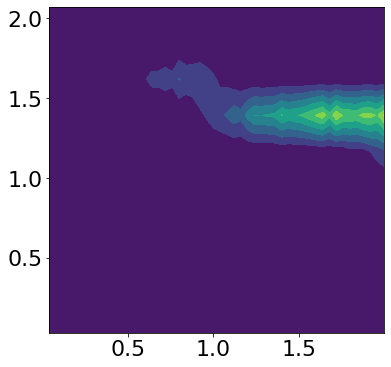

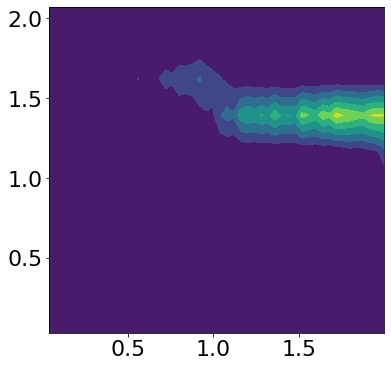

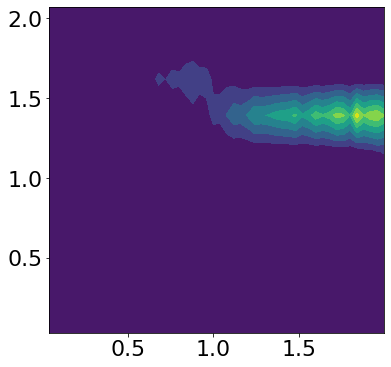

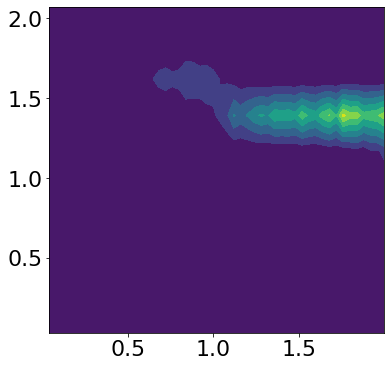

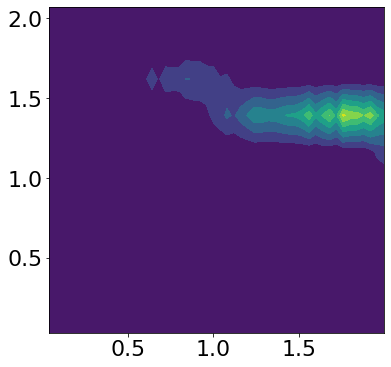

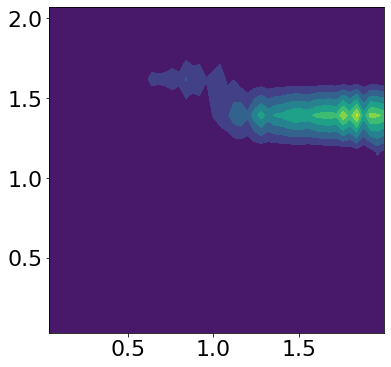

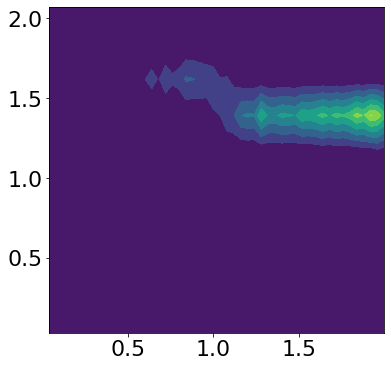

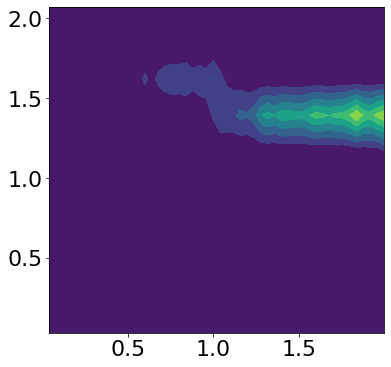

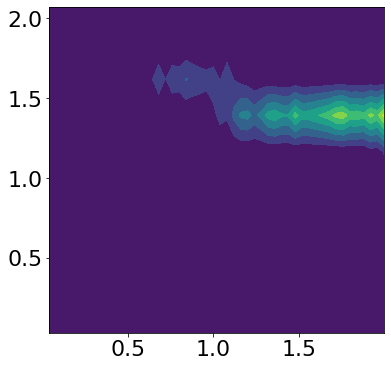

In [109]:
counts, bins = np.histogramdd(samples, bins=(50, 10, 30))

#ax.imshow(counts[0], interpolation="bilinear", cmap=cm.viridis)#,
          #extent=(np.min(bins[1]), np.max(bins[1]), np.min(bins[2]), np.max(bins[2])))
    
    
x = np.linspace(np.min(bins[0]), np.max(bins[0]), len(bins[0])-1) # f
y = np.linspace(np.min(bins[1]), np.max(bins[1]), len(bins[1])-1) # gamma
z = np.linspace(np.min(bins[2]), np.max(bins[2]), len(bins[2])-1) # rs

[X, Y] = np.meshgrid(x, y)
for i in range(len(bins[2])-1):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.contourf(X, Y, counts[:, :, i].T)

# Einasto profile w/ multinest

In [2]:
!ls /home/mariacst/exoplanets/debug/multinest/einasto/out/101/

T650_multinest_N1000_gamma1.2_rs10.0_v101.txt
T650_multinest_N1000_gamma1.2_rs10.0_v101IS.iterinfo
T650_multinest_N1000_gamma1.2_rs10.0_v101IS.points
T650_multinest_N1000_gamma1.2_rs10.0_v101IS.ptprob
T650_multinest_N1000_gamma1.2_rs10.0_v101ev.dat
T650_multinest_N1000_gamma1.2_rs10.0_v101live.points
T650_multinest_N1000_gamma1.2_rs10.0_v101phys_live.points
T650_multinest_N1000_gamma1.2_rs10.0_v101post_equal_weights.dat
T650_multinest_N1000_gamma1.2_rs10.0_v101resume.dat
T650_multinest_N1000_gamma1.2_rs10.0_v101stats.dat
T650_multinest_N1000_gamma1.2_rs10.0_v101summary.txt
T650_multinest_N100_gamma1.2_rs10.0_v101.txt
T650_multinest_N100_gamma1.2_rs10.0_v101IS.iterinfo
T650_multinest_N100_gamma1.2_rs10.0_v101IS.points
T650_multinest_N100_gamma1.2_rs10.0_v101IS.ptprob
T650_multinest_N100_gamma1.2_rs10.0_v101ev.dat
T650_multinest_N100_gamma1.2_rs10.0_v101live.points
T650_multinest_N100_gamma1.2_rs10.0_v101phys_live.points
T650_multinest_N100_gamma1.2_rs10.0_v101post_equal_weights.dat
T650

In [4]:
filepath = "/home/mariacst/exoplanets/debug/multinest/einasto/out/101/"
_file    = filepath + "T650_multinest_N100_gamma1.2_rs10.0_v101post_equal_weights.dat"
samples  = np.genfromtxt(_file, unpack=True)

Text(0.5, 0, '$\\gamma$')

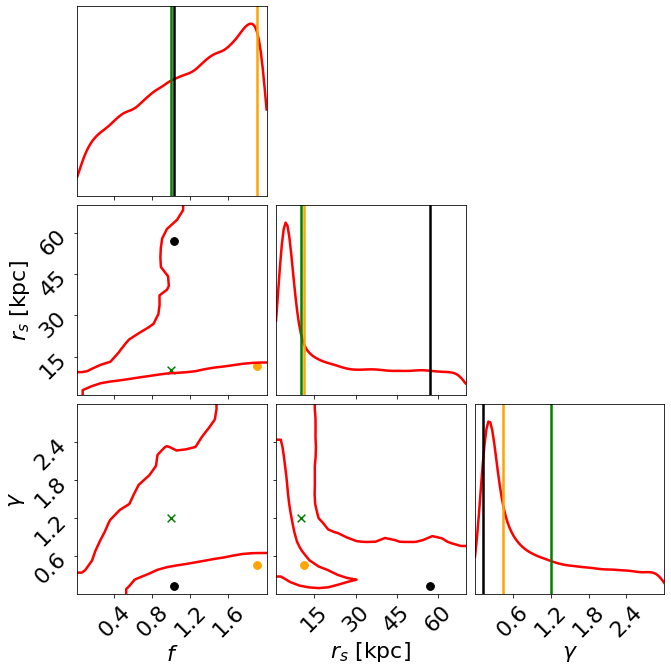

In [10]:
smooth=1.

gamma=1.2; rs=10.; f=1.

fig, axes = corner(np.array([samples[0], samples[2], samples[1]]).T, 
                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth, color="red",)
# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 4, 8], np.array([samples[0], samples[2], samples[1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="red", lw=2.5)   
    
axes[0, 0].axvline(1., color="g", ls="-", lw=2.5); axes[1, 1].axvline(rs, color="g", ls="-", lw=2.5); 
axes[2, 2].axvline(gamma, color="g", ls="-", lw=2.5); axes[1, 0].scatter(f, rs, marker="x", color="g", s=60); 
axes[2, 0].scatter(f, gamma, marker="x", color="g", s=60); axes[2, 1].scatter(rs, gamma, marker="x", color="g", s=60);

gamma=0.128967135512679437E+00; f=0.102326114434090987E+01; rs=0.570431942228791797E+02
axes[0, 0].axvline(f, color="k", ls="-", lw=2.5); axes[1, 1].axvline(rs, color="k", ls="-", lw=2.5); 
axes[2, 2].axvline(gamma, color="k", ls="-", lw=2.5); axes[1, 0].scatter(f, rs, marker="o", color="k", s=60); 
axes[2, 0].scatter(f, gamma, marker="o", color="k", s=60); 
axes[2, 1].scatter(rs, gamma, marker="o", color="k", s=60);

gamma=0.4551418254270739; f=1.900495817765319; rs=11.402960780521408
axes[0, 0].axvline(f, color="orange", ls="-", lw=2.5); 
axes[1, 1].axvline(rs, color="orange", ls="-", lw=2.5); 
axes[2, 2].axvline(gamma, color="orange", ls="-", lw=2.5); 
axes[1, 0].scatter(f, rs, marker="o", color="orange", s=60); 
axes[2, 0].scatter(f, gamma, marker="o", color="orange", s=60); 
axes[2, 1].scatter(rs, gamma, marker="o", color="orange", s=60);


axes[1, 0].set_ylabel(r"$r_s$ [kpc]"); axes[2, 0].set_xlabel(r"$f$"); axes[2, 0].set_ylabel(r"$\gamma$")
axes[2, 1].set_xlabel(r"$r_s$ [kpc]"); axes[2, 2].set_xlabel(r"$\gamma$")

v4
N=100   [103 107 110 116 123 127 142 143 148 187 191 193]
v0


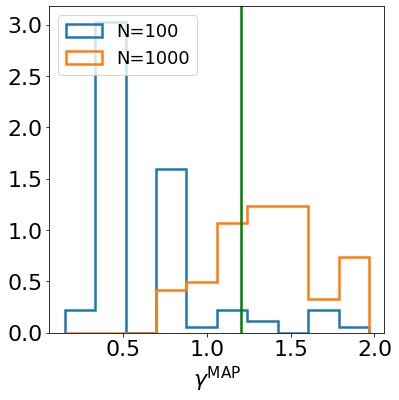

In [18]:
path = "/home/mariacst/exoplanets/results/"
true = 1.2
FSE  = []
N    = [100, 1000]
rank = 100.
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
i=0
for nBDs in N:
    mode = np.genfromtxt(path + "statistics_multinest_einasto_N%i_gamma1.2rs10.0"%nBDs, unpack=True)[1]
    print(v[i])
    i+=1
    if nBDs<200:
        counts, bins, _ = ax.hist(mode, histtype="step", lw=2.5, density=True, label="N=%i"%nBDs);
        pos = np.where(mode>1)
        print("N=100  ", pos[0]+101)
    else:
        ax.hist(mode, bins=bins, histtype="step", lw=2.5, density=True, label="N=%i"%nBDs);
    FSE.append(np.sqrt(1/rank*np.sum(np.power(mode - true, 2)))/true)
ax.set_xlabel(r"$\gamma^{\rm MAP}$"); ax.legend(fontsize=18)
ax.axvline(true, color="green", lw=2.5)

In [15]:
FSE

[0.542117276736419, 0.6678237558584517]

In [20]:
def return_ML(filepath):
    ML = []
    with open(filepath) as f:
        for val in f.readlines():
            #print(val)
            val = val.replace("\n","")
            val = val.split('   ')
            ML = [float(val[7]), float(val[8]), float(val[9])]
            break
    return ML

In [25]:
i=0
N=100
return_ML(path + "%i/T650_multinest_N%i_gamma1.2_rs10.0_v%isummary.txt"%(i+101, N, i+101))

[0.2132339182686267, 1.3537775491368802, 2.9315070183395084]

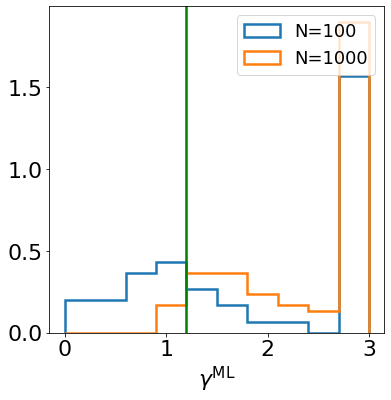

In [22]:
path = "/home/mariacst/exoplanets/debug/multinest/einasto/out/"
#path   = "/hdfs/local/mariacst/exoplanets/results/multinest/onlySigmaT/sampling_efficiency_1/"
rank   = 100
true   = 1.2
N      = [100, 1000]
ML     = []
FSE_ML = []
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
for k in range(len(N)):
    ML.append([])
    for i in range(rank):
        ML[k].append(return_ML(path + "%i/T650_multinest_N%i_gamma1.2_rs10.0_v%isummary.txt"%(i+101, N[k], i+101))) 
    ML[k] = np.array(ML[k])
    
    if N[k]<200:
        counts, bins, _ = ax.hist(ML[k][:, 1], histtype="step", lw=2.5, label="N=%i"%N[k], density=True);
    else:
        ax.hist(ML[k][:, 1], histtype="step", bins=bins, lw=2.5, label="N=%i"%N[k], density=True)
    #print(ML[k][:, 1])
    FSE_ML.append(np.sqrt(1/rank*np.sum(np.power(ML[k][:, 1] - true, 2)))/true)

ax.set_xlabel(r"$\gamma^{\rm ML}$"); ax.legend(fontsize=18)
ax.axvline(true, color="green", lw=2.5)

In [23]:
FSE_ML

[1.0664344071214635, 1.178478666218564]

# Testing new density profile

\begin{equation}
\rho(r) = \frac{\rho_{\rm scale}}{r^{\alpha}} = \frac{\rho_0 R_0^{\alpha}}{r^{\alpha}}
\end{equation}

In [2]:
from utils import gNFW_rho

In [6]:
r  = np.linspace(0.1, 1., 200)
R0 = 8.178
rho1 = gNFW_rho(R0, r, [1., 20., 0.42])
rho1bis = gNFW_rho(R0, r, [0.1, 20., 0.42])

rho_rs1 = gNFW_rho(R0, r, [1., 5., 0.42])
rho_rs2 = gNFW_rho(R0, r, [1., 10., 0.42])


def PL_rho(R0, r, alpha, rho0):
    return(1/np.power(r, alpha))

rho2 = PL_rho(R0, r, 1, 0.42)*rho1[-1]
rho3 = PL_rho(R0, r, 0.1, 0.42)*rho1bis[-1]

In [4]:
print(rho1)

[67.5032389  64.55337266 61.84821458 59.35852959 57.05956119 54.93020549
 52.9523615  51.11041542 49.39082758 47.78179915 46.27300102 44.85535192
 43.52083547 42.26234856 41.07357487 39.94887889 38.8832166  37.87205982
 36.91133197 35.99735308 35.12679275 34.29662956 33.5041161  32.74674856
 32.02224033 31.32849894 30.6636059  30.02579897 29.41345659 28.82508407
 28.2593015  27.71483285 27.19049645 26.68519638 26.19791486 25.72770536
 25.27368655 24.8350367  24.41098878 24.00082597 23.60387759 23.21951549
 22.84715071 22.48623047 22.13623541 21.79667717 21.46709604 21.14705892
 20.83615742 20.53400614 20.24024104 19.95451799 19.67651146 19.40591322
 19.14243128 18.88578877 18.635723   18.39198456 18.15433652 17.9225536
 17.69642151 17.47573626 17.2603036  17.04993836 16.844464   16.64371207
 16.4475218  16.25573959 16.06821869 15.88481879 15.70540566 15.52985085
 15.35803136 15.18982937 15.02513195 14.86383084 14.70582219 14.55100632
 14.39928757 14.25057402 14.1047774  13.96181281 13.

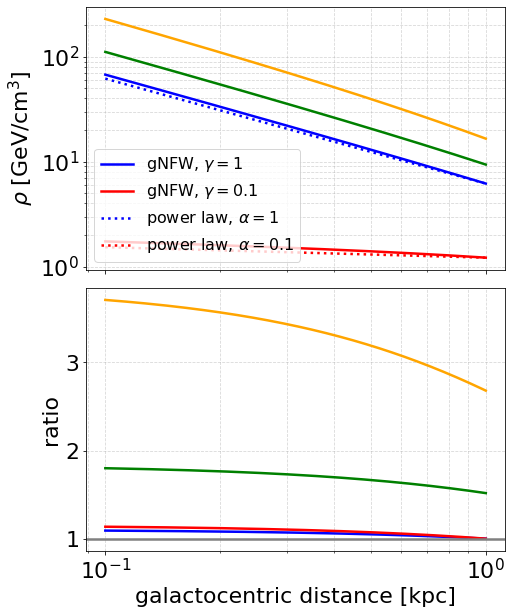

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(7.5, 10), sharex=True)
ax[0].plot(r, rho1, color="blue", lw=2.5, label=r"gNFW, $\gamma=1$")
ax[0].plot(r, rho1bis, color="red", lw=2.5, label=r"gNFW, $\gamma=0.1$")

ax[0].plot(r, rho_rs1, color="orange", lw=2.5)
ax[0].plot(r, rho_rs2, color="green", lw=2.5)


ax[0].plot(r, rho2, color="blue", ls=":", lw=2.5, label=r"power law, $\alpha=1$")
ax[0].plot(r, rho3, color="red", ls=":", lw=2.5, label=r"power law, $\alpha=0.1$")
#ax.axvline(R0, ls="--", color="grey", lw=2.5)


ax[1].plot(r, rho1/rho2, color="blue", lw=2.5)

ax[1].plot(r, rho_rs1/rho2, color="orange", lw=2.5)
ax[1].plot(r, rho_rs2/rho2, color="green", lw=2.5)

ax[1].plot(r, rho1bis/rho3, color="red", lw=2.5); ax[1].axhline(1, color="grey", lw=2.5)
ax[1].grid(which="both", ls="--", alpha=0.5); ax[1].set_ylabel("ratio")

ax[0].grid(which="both", ls="--", alpha=0.5)
ax[0].set_ylabel(r"$\rho$ $\rm [GeV/cm^3]$")
ax[1].set_xlabel("galactocentric distance [kpc]")
ax[0].set_yscale("log"); ax[0].set_xscale("log")
ax[0].legend(fontsize=16); fig.subplots_adjust(hspace=0.07)
fig.savefig("rhoDM_gNFW_vs_powerlaw.pdf", bbox_inches="tight")

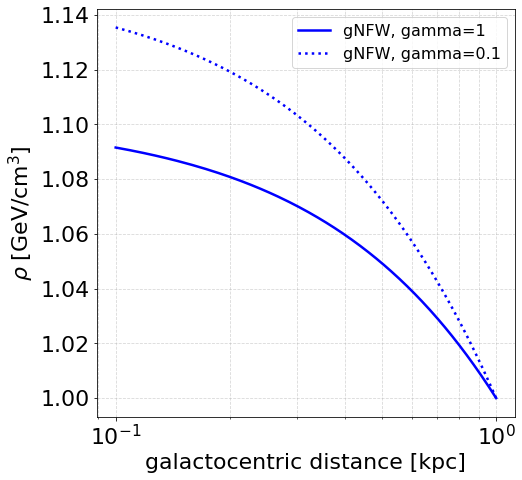

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(7.5, 7.5))
ax.plot(r, rho1/rho2, color="blue", lw=2.5, label="gNFW, gamma=1")
ax.plot(r, rho1bis/rho3, color="blue", ls=":", lw=2.5, label="gNFW, gamma=0.1")

ax.grid(which="both", ls="--", alpha=0.5)
ax.set_ylabel(r"$\rho$ $\rm [GeV/cm^3]$")
ax.set_xlabel("galactocentric distance [kpc]")
#ax.set_yscale("log")
ax.set_xscale("log")
ax.legend(fontsize=16)

In [1]:
!ls /home/mariacst/exoplanets/debug/multinest/power_law/

100_slurm.sh	fitting_Ntimes.py   multinest_functions.py
__pycache__	logs		    out
derivatives.py	mock_generation.py  utils.py


In [4]:
import sys                                                                         
sys.path.append("/home/mariacst/exoplanets/running/.env/lib/python3.6/site-packages")
sys.path.append("/home/sven/exoplanetenv/lib/python3.6/site-packages")          
import numpy as np                                                                 
from scipy.interpolate import griddata                                             
import imp
sys.path.append("/home/mariacst/exoplanets/debug/multinest/power_law/")
import mock_generation                                                             
imp.reload(mock_generation)                                                        
from mock_generation import mock_population_all                                    
from astropy.constants import R_jup                                                
import glob                                                                        
import pickle                                                                      
from scipy.interpolate import interp1d                                             
import matplotlib.pyplot as plt                                                                                                   
import time                                                                        
                                                                                   
# Constant parameters & conversions ==========================================     
rho0                    = 0.42 # Local DM density [GeV/cm3]                     
epsilon                 = 1.                                                       
Rsun                    = 8.178 # Sun galactocentric distance [kpc]                
conv_Msun_to_kg         = 1.98841e+30 # [kg/Msun]                                  
# ============================================================================     
# Input parameters                                                              
ex         = "test"                                                          
rank       = 101                                                     
nBDs       = 100                                                    
relTobs    = 0.1                                                                   
sigma      = 0.#float(sys.argv[4])                                                 
f_true     = 1.                                                                    
gamma_true = 1.2                                                    
rs_true    = 10                                                   
v          = 100.                                                                  
Tcut       = 650.                                                                  
# ------------------------------------------------------------------------         
# Load theoretical cooling model                                                   
path = "/home/mariacst/exoplanets/running/data/"                                   
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)               
points = np.transpose(data[0:2, :])                                                
values = data[2]                                                                   
# Mock observation                                                                 
np.random.seed(rank)                                                               
(robs, sigmarobs, Tobs, sigmaTobs, Mobs,                                           
     sigmaMobs, Aobs, sigmaAobs) = mock_population_all(nBDs, relTobs, sigma,       
                                      sigma, sigma, f_true, gamma_true,
                                      rs_true, rho0_true=rho0, Tmin=Tcut, v=v)

In [11]:
import utils
imp.reload(utils)
from utils import PL_T_DM

In [12]:
PL_T_DM(robs, Mobs*conv_Msun_to_kg, 10., 0.01, 100.)

array([368.62003601, 327.9049715 , 346.21756213, 371.7328469 ,
       336.97309167, 309.49154992, 352.76655622, 344.05538373,
       324.47618424, 369.65342268, 347.08687095, 331.9343704 ,
       367.33434651, 370.57221786, 350.59514007, 367.09210984,
       370.06796052, 318.77567978, 301.82528596, 371.82422393,
       335.22483603, 326.41493079, 350.19960561, 337.47812304,
       358.32893836, 343.96174929, 319.86558921, 345.90592774,
       371.10716219, 298.11845497, 365.00580465, 346.88566525,
       350.18002184, 351.37329951, 347.76331721, 361.24188648,
       328.22198555, 370.95935806, 359.74757174, 311.44137893,
       356.39195923, 324.95219793, 337.44335543, 328.77744413,
       364.64010311, 353.69972131, 311.2488493 , 331.96993596,
       367.03241273, 307.78837228, 371.89315306, 356.05469674,
       366.80997817, 350.79275655, 371.51472462, 371.1414561 ,
       362.20958425, 316.12725736, 368.0225955 , 335.12107983,
       350.99520061, 329.65688995, 350.09705344, 349.17

In [18]:
filepath = "/home/mariacst/exoplanets/debug/multinest/power_law/non_linear/out/"
#filepath = "/home/mariacst/exoplanets/debug/multinest/power_law/out/"
rank = 25; gamma=0.5; rs=20.
_file = filepath + "%i/T650_multinest_N1000_sigma0.3_gamma%.1f_rs%.1f_v%ipost_equal_weights.dat"%(rank, gamma, rs, rank)
samples = np.genfromtxt(_file, unpack=True)

_file = filepath + "wider/%i/T650_multinest_N100_sigma0.3_gamma%.1f_rs%.1f_v%ipost_equal_weights.dat"%(rank, gamma, rs, rank)
samples2 = np.genfromtxt(_file, unpack=True)

#rank=87
#_file    = filepath + "%i/T650_multinest_N1000_gamma%.1f_rs5.0_v%ipost_equal_weights.dat"%(rank, gamma, rank)
#samples3 = np.genfromtxt(_file, unpack=True)

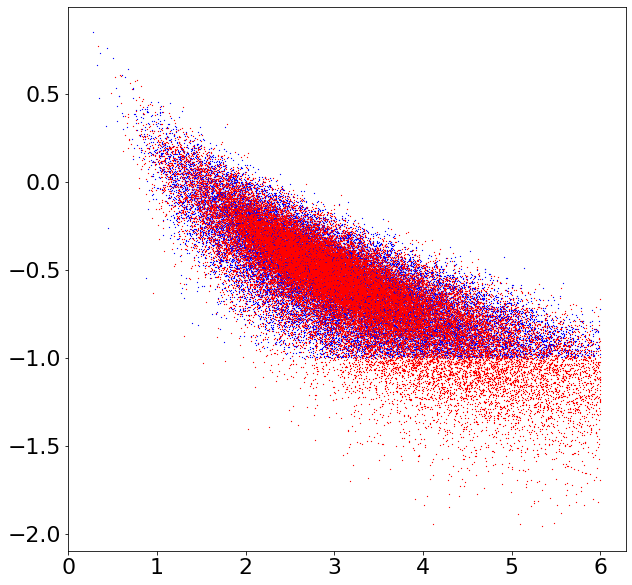

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(samples[0], samples[1], marker="x", s=0.1, color="blue")
ax.scatter(samples2[0], samples2[1], marker="x", s=0.1, color="red")


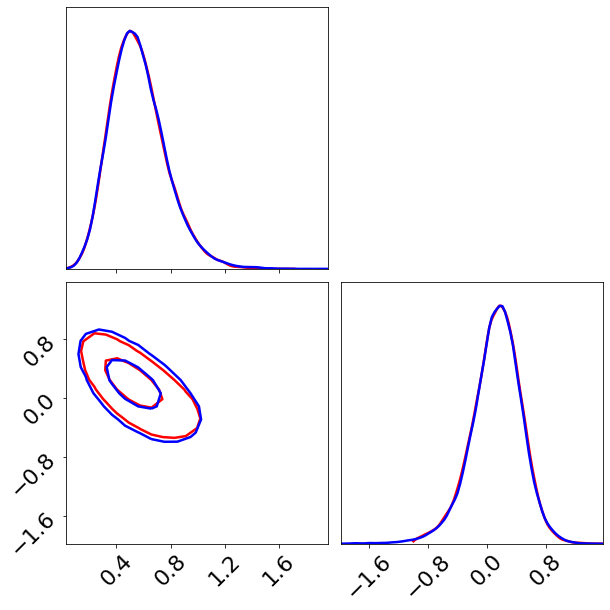

In [19]:
smooth=1.

fig, axes = corner(np.array([samples[0], samples[1]]).T, 
                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth, color="red")
                   #range=((0, 80), (0.8, 1.5)))
# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 3], np.array([samples[0], samples[1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="red", lw=2.5)   

    
corner(np.array([samples2[0], samples2[1]]).T, 
                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth, color="blue", fig=fig)

for axidx, samps in zip([0, 3], np.array([samples2[0], samples2[1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="blue", lw=2.5) 
    
#corner(np.array([samples3[0], samples3[1]]).T, 
#                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
#                   plot_density=False, fill_contours=False, smooth=smooth, color="green", fig=fig)

#for axidx, samps in zip([0, 3], np.array([samples3[0], samples3[1]])):
#    kde   = gaussian_kde(samps)
#    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
#    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="green", lw=2.5)

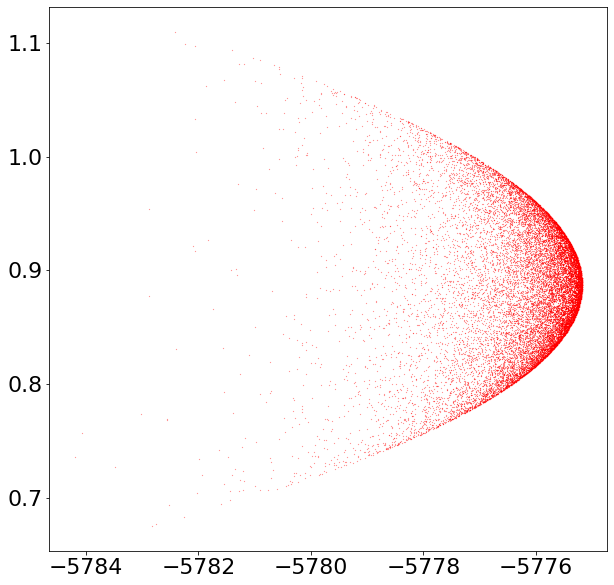

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.scatter(samples3[2], samples3[1], marker=".", color="red", s=0.1)


#ax.axhline(1.0308456653111742); ax.axhline(0.73); ax.axhline(1.36)
#ax.axvline(np.max(samples[2])-1.)

In [90]:
from scipy.interpolate import UnivariateSpline
from scipy.optimize import minimize

def LI(L, samples, bin_n=20, verbose=False):
    """
    For each parameter, construct profile likelihood and return the profile likelihood interval
    (i.e. region where the log Likelihood is within 1 of its maximum value)
    
    """   
    # Create bins in Likelihood vs parameter space, find the max Likelihood 
    # value in each bin and the corresponding parameter values
    x = binned_statistic(samples, -L, 'min', bins=bin_n)[1] 
    y = binned_statistic(samples, -L, 'min', bins=bin_n+1)[0]
    
    # Create Interpolation fanction Likelihood - parameter
    #pdb.set_trace()
    z =  UnivariateSpline(x[~np.isnan(y)], y[~np.isnan(y)], s=0)
    
    # Find in which points crosses 1sigma horizontal line (where 1 sigma 
    # corresponds to 1/2 -for 1 dof-)
    x_tmin     = np.min(samples)
    epsilon    = 1
    niteration = 0
    logLmin    = np.min(y[~np.isnan(y)]) + 1.
    while epsilon > 10**-6 and niteration < 20:
        niteration +=1
        minimum = minimize(lambda x: (z(x)-logLmin)**2, x_tmin,
                           bounds=((np.min(samples), samples[np.argmax(L)]),))
        epsilon = minimum.fun
        x_tmin  = x_tmin*1.1
        _min    = minimum.x
        
    if epsilon < 10**-6:
        LImin = _min[0]
    else:
        LImin = np.min(samples)
        
    x_tmax     = samples[np.argmax(L)]
    epsilon    = 1
    niteration = 0
    while epsilon > 10**-6 and niteration < 25:
        niteration +=1
        maximum = minimize(lambda x: (z(x)-logLmin)**2, x_tmax, 
                           bounds=((samples[np.argmax(L)], np.max(samples)),))
        epsilon  = maximum.fun
        x_tmax  = x_tmax*1.1
        _max    = maximum.x
    
    if epsilon < 10**-6:
        LImax = _max[0]
    else:
        LImax = np.max(samples)

    if verbose==True:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.plot(x, y, color="k", lw=2.5)
        ax.axvline(LImin, color="g"); ax.axvline(LImax, color="g")

    #Return
    return  LImin, LImax

In [103]:
_file   = filepath + "T650_multinest_N100_gamma1.2_rs10.0_v101post_equal_weights.dat"
#print(_file)
samples = np.genfromtxt(_file, unpack=True)

samples[1][np.argmax(samples[2])]

LI(samples[2], samples[1], bin_n=60)

(0.7300982661319861, 1.3679806235628205)

In [60]:
filepath = "/hdfs/o" 
nBDs=100; j=1
for i in [101]:#, 105]:#, 106, 111, 112]:
    file_name  = (filepath + "%i/"%(i) +                                
                     ("T650_multinest_N%i_gamma1.2_rs10.0_v%ipost_equal_weights.dat"
                     %(nBDs, i)))
    samples    = np.genfromtxt(file_name, unpack=True)

    _n, _bins    = np.histogram(samples[j], bins=50)
    print(_bins[np.argmax(_n)])


101 0.21173610683734384 32498 True
0.9966788024729771 1.1646789499965022
[1.08067888]
0.9686787778857229


In [16]:
def return_MAP(samples, nbins=50):
    _n, _bins = np.histogram(samples, bins=nbins)
    return(_bins[np.argmax(_n)])

[0.14542650697398166, 0.11891167571165827]


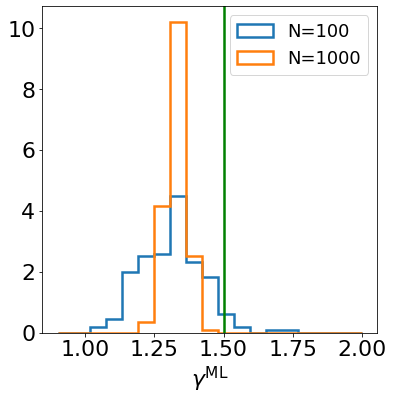

In [17]:
path = "/hdfs/local/mariacst/exoplanets/results/multinest/onlySigmaT/power_law/extra_wider/"
gamma   = 1.5; rank=200
rs      = 5.
N       = [100, 1000]
MAP     = []
FSE_MAP = []
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
bins=np.linspace(0.9, 2, 20)
rank=200

for k in range(len(N)):
    MAP.append([])
    for i in range(rank):
        _file   = path + "%i/T650_multinest_N%i_gamma%.1f_rs%.1f_v%ipost_equal_weights.dat"%(i+1, N[k], gamma, rs, i+1)
        #print(_file)
        samples = np.genfromtxt(_file, unpack=True)
        MAP[k].append(return_MAP(samples[1])) 
        
    MAP[k] = np.array(MAP[k])
    
    ax.hist(MAP[k], histtype="step", bins=bins, lw=2.5, label="N=%i"%N[k], density=True);
    #print(ML[k][:, 1])
    FSE_MAP.append(np.sqrt(1/rank*np.sum(np.power(MAP[k] - gamma, 2)))/gamma)

ax.set_xlabel(r"$\gamma^{\rm ML}$"); ax.legend(fontsize=18)
ax.axvline(gamma, color="green", lw=2.5)
print(FSE_MAP)

[0.11891332212068494]


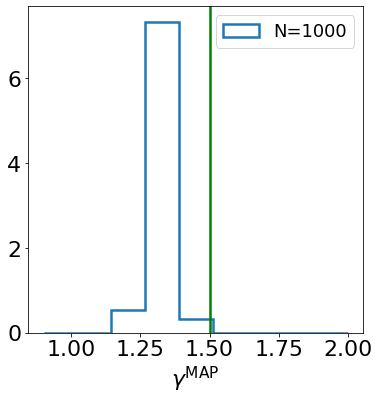

In [23]:
path    = "/home/mariacst/exoplanets/results/power_law/onlySigmaT/statistics_" 
gamma   = 1.5
rs      = 5.
N       = [1000]#, 1000]
MAP     = []
FSE_MAP = []; FSE_mean = []; FSE_median = []; FSE_ML = []; ex="T650_multinest"
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for k in range(len(N)):

    _file   = path + ex + "_N%i_gamma%.1frs%.1f_1_200_extra_wider"%(N[k], gamma, rs)

    data = np.genfromtxt(_file, unpack=True)
    
    mean   = data[0]
    median = data[1]
    MAP    = data[4]
    ML     = data[7]
    
    if N[k]<200:
        bins=np.linspace(0.9, 2, 10)
        counts, bins, _ = ax.hist(MAP, histtype="step", lw=2.5, label="N=%i"%N[k], density=True, bins=bins);
    else:
        ax.hist(MAP, histtype="step", bins=bins, lw=2.5, label="N=%i"%N[k], density=True)
        
    rank = len(mean)

    FSE_mean.append(np.sqrt(1/rank*np.sum(np.power(mean - gamma, 2)))/gamma)
    FSE_median.append(np.sqrt(1/rank*np.sum(np.power(median - gamma, 2)))/gamma)
    FSE_MAP.append(np.sqrt(1/rank*np.sum(np.power(MAP - gamma, 2)))/gamma)
    FSE_ML.append(np.sqrt(1/rank*np.sum(np.power(ML - gamma, 2)))/gamma)

ax.set_xlabel(r"$\gamma^{\rm MAP}$"); ax.legend(fontsize=18)
ax.axvline(gamma, color="green", lw=2.5)

print(FSE_MAP)

[0.22477180017866025, 0.20354146539055215]
[0.22805451550987635, 0.2037465685055279]
[0.24170791293993207, 0.20662786974548122]
[0.21621535601750808, 0.2021578763683913]


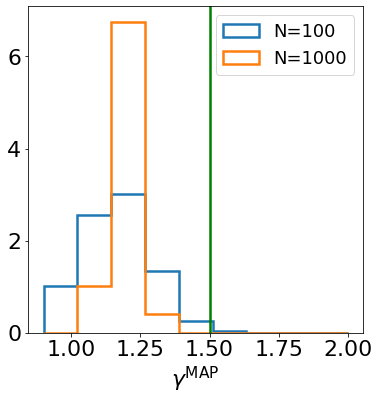

In [25]:
path    = "/home/mariacst/exoplanets/results/power_law/onlySigmaT/statistics_" 
gamma   = 1.5
rs      = 10.
N       = [100, 1000]#, 1000]
MAP     = []
FSE_MAP = []; FSE_mean = []; FSE_median = []; FSE_ML = []; ex="T650_multinest"
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for k in range(len(N)):

    _file   = path + ex + "_N%i_gamma%.1frs%.1f_1_200_extra_wider"%(N[k], gamma, rs)

    data = np.genfromtxt(_file, unpack=True)
    
    mean   = data[0]
    median = data[1]
    MAP    = data[4]
    ML     = data[7]
    
    if N[k]<200:
        bins=np.linspace(0.9, 2, 10)
        counts, bins, _ = ax.hist(MAP, histtype="step", lw=2.5, label="N=%i"%N[k], density=True, bins=bins);
    else:
        ax.hist(MAP, histtype="step", bins=bins, lw=2.5, label="N=%i"%N[k], density=True)
        
    rank = len(mean)

    FSE_mean.append(np.sqrt(1/rank*np.sum(np.power(mean - gamma, 2)))/gamma)
    FSE_median.append(np.sqrt(1/rank*np.sum(np.power(median - gamma, 2)))/gamma)
    FSE_MAP.append(np.sqrt(1/rank*np.sum(np.power(MAP - gamma, 2)))/gamma)
    FSE_ML.append(np.sqrt(1/rank*np.sum(np.power(ML - gamma, 2)))/gamma)

ax.set_xlabel(r"$\gamma^{\rm MAP}$"); ax.legend(fontsize=18)
ax.axvline(gamma, color="green", lw=2.5)

print(FSE_mean)
print(FSE_median)
print(FSE_MAP)
print(FSE_ML)

In [6]:
#print(FSE_mean)
#print(FSE_median)
print(FSE_MAP)
#print(FSE_ML)

[0.6981647282697687, 0.5433758711978293]


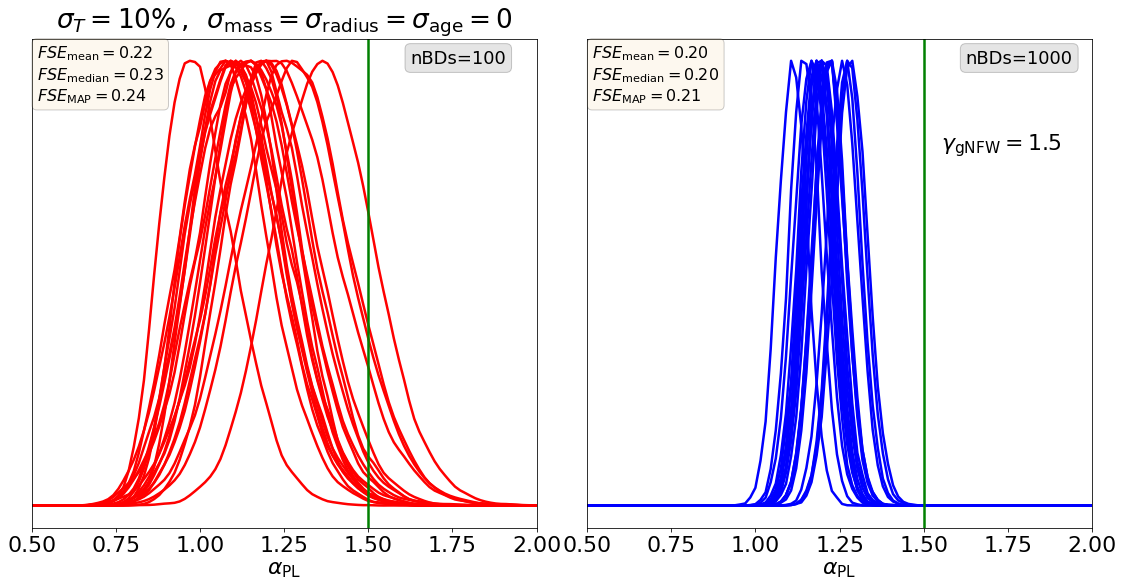

In [47]:
filepath  = "/hdfs/local/mariacst/exoplanets/results/multinest/onlySigmaT/power_law/extra_wider/"

gamma=1.5; rs=10.; sigma=0.1

fig, ax = plt.subplots(1, 2, figsize=(19, 9), sharex=True)
ax[0].set_xlim(0.5, 2)#; ax[1].set_xlim(0.9, 2)
xvals = ax[0].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
fig.subplots_adjust(wspace=0.1)

bins = np.linspace(0.8, 2.1, 20) 

for rank in range(20):
    _file    = filepath + "%i/T650_multinest_N%i_gamma%.1f_rs%.1f_v%ipost_equal_weights.dat"%(rank+1, 
                                                                                              100, gamma, rs, rank+1)
    samples  = np.genfromtxt(_file, unpack=True)[1]
    
    kde = gaussian_kde(samples)
    ax[0].plot(xvals, kde(xvals)/np.max(kde(xvals)), lw=2.5, color="red") 
    
    
    _file    = filepath + "%i/T650_multinest_N%i_gamma%.1f_rs%.1f_v%ipost_equal_weights.dat"%(rank+1, 
                                                                                              1000, gamma, rs, rank+1)
    samples  = np.genfromtxt(_file, unpack=True)[1]
    
    kde = gaussian_kde(samples)
    ax[1].plot(xvals, kde(xvals)/np.max(kde(xvals)), lw=2.5, color="blue") 
    
    #ax.hist(samples[1], bins=bins, histtype="step", density=True, lw=2.5)#, color=colors[rank]);
    #ax.axvline(data[0][rank], color=colors[rank], lw=2.5)
    
ax[0].set_yticks([]); ax[1].set_yticks([]); ax[0].axvline(gamma, color="green", lw=2.5)
ax[1].axvline(gamma, color="green", lw=2.5); ax[1].text(1.55, 0.8, r"$\gamma_{\rm gNFW}=1.5$")
ax[0].set_xlabel(r"$\alpha_{\rm PL}$"); ax[1].set_xlabel(r"$\alpha_{\rm PL}$")

props = dict(boxstyle='round', facecolor='wheat', alpha=0.2)
textstr = '\n'.join((
    r'$FSE_{\rm mean}=%.2f$' % (FSE_mean[0], ),
    r'$FSE_{\rm median}=%.2f$' % (FSE_median[0], ),
    r'$FSE_{\rm MAP}=%.2f$' % (FSE_MAP[0], )))
ax[0].text(0.01, 0.99, textstr, transform=ax[0].transAxes, fontsize=16,
           verticalalignment='top', bbox=props)

textstr = '\n'.join((
    r'$FSE_{\rm mean}=%.2f$' % (FSE_mean[1], ),
    r'$FSE_{\rm median}=%.2f$' % (FSE_median[1], ),
    r'$FSE_{\rm MAP}=%.2f$' % (FSE_MAP[1], )))
ax[1].text(0.01, 0.99, textstr, transform=ax[1].transAxes, fontsize=16,
           verticalalignment='top', bbox=props)

props = dict(boxstyle='round', facecolor='grey', alpha=0.2)
ax[0].text(0.75, 0.95, "nBDs=100", transform=ax[0].transAxes, fontsize=18, bbox=props)
ax[1].text(0.75, 0.95, "nBDs=1000", transform=ax[1].transAxes, fontsize=18, bbox=props)

ax[0].set_title(r"$\sigma_T=10\%\,,\,\,\, \sigma_{\rm mass}=\sigma_{\rm radius}=\sigma_{\rm age}=0$")

fig.savefig("1Dposterior_alpha_sigma=0.pdf", bbox_inches="tight")

In [2]:
path = "/home/mariacst/exoplanets/results/power_law/sigma/"

nBDs = [100, 1000]
sigma = [0.3]

gamma = [0.5, 0.6, 0.8, 1.2, 1.4, 1.5]
rs    = [5, 20]

PE     = ["mean", "median", "mode", "ML"]
color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

x_axis = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


def plot_FSE_pe(path, v, pe, marker, fig=None, ax=None):

    if not fig:
        fig, ax = plt.subplots(1, 1, figsize=(11, 5)) 
    ax.set_title(pe)
    for s in sigma:
        for n in nBDs:
            x=0
            if n<200:
                color="red"
            else:
                color="blue"
            for _rs in rs:
                for _g in gamma:
                    try:
                        data = np.genfromtxt(path + "statistics_T650_multinest" +           
                                 ("_N%i_sigma%.1f_gamma%.1frs%.1f_1_200_"%(n, s, _g, _rs)) + v, unpack=True) 
                    except:
                        data = np.genfromtxt(path + "statistics_T650_multinest" +           
                                 ("_N%i_sigma%.1f_gamma%.1frs%.1f_1_200_"%(n, s, _g, _rs)) + v, unpack=True)  
                    if pe=="median":                                                       
                        _pe = data[1]                                                       
                    elif pe=="mode":                                                       
                        _pe = data[4]                                                       
                    elif pe=="mean":                                                       
                        _pe = data[0]                                                       
                    elif pe=="ML":                                                         
                        _pe = data[7]                                                       
                    else:                                                                  
                        sys.exit("Point estimate not implemented!") 
                    rank=len(data[0])
                    FSE=np.sqrt(1/rank*np.sum(np.power(_pe - _g, 2)))/_g                     
                    ax.scatter(x, FSE, color=color, marker=marker)#, label="N=%i"%n)
                    ax.axvline(x, ls="--", alpha=0.2)
                    x+=1
    ax.set_xticks(x_axis) 
    ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.8, 5)', '(1.2, 5)', '(1.4, 5)', '(1.5, 5)', 
                        '(0.5, 20)', '(0.6, 20)', '(0.8, 20)', '(1.2, 20)', '(1.4, 20)', '(1.5, 20)'
                       ], rotation=80);
    return fig, ax

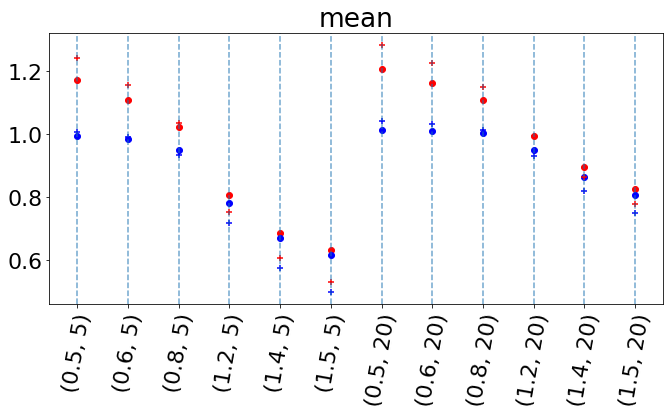

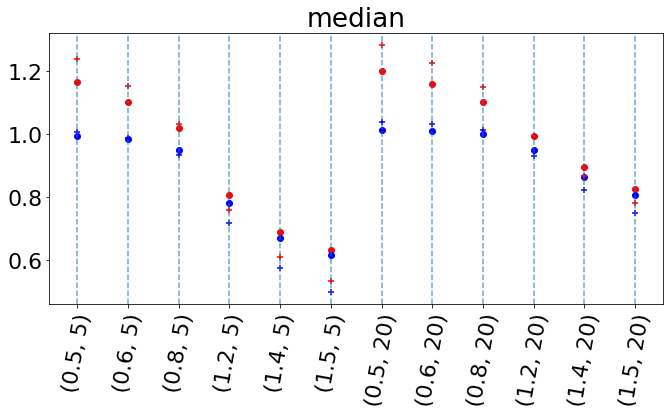

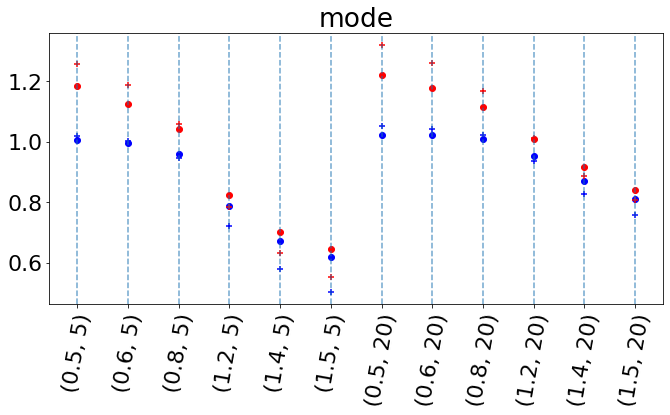

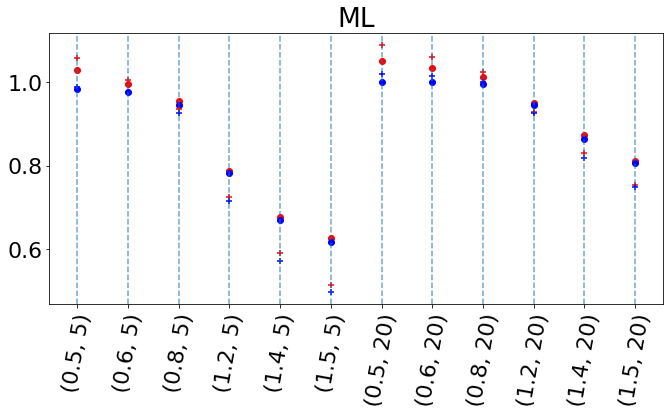

In [3]:
for pe in PE:
    fig, ax = plot_FSE_pe(path, "final", pe, "o")
    plot_FSE_pe(path, "final_non_linear", pe, "+", fig, ax)

In [6]:
path = "/home/mariacst/exoplanets/results/power_law/sigma/"

nBDs = [100, 1000]
sigma = [0.3]

gamma = [0.5, 0.6, 0.8, 1.2, 1.4, 1.5]
rs    = [5, 20]

PE     = ["mean", "median", "mode", "ML"]
color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

x_axis = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]#, 12, 13, 14, 15, 16, 17]


def plot_FSE_pe(path, v, v2, pe, marker, fig=None, ax=None):

    if not fig:
        fig, ax = plt.subplots(1, 1, figsize=(11, 5)) 
    ax.set_title(pe)
    for s in sigma:
        for n in nBDs:
            x=0
            if n<200:
                color="red"
            else:
                color="blue"
            for _rs in rs:
                for _g in gamma:
                    try: 
                        data = np.genfromtxt(path + "statistics_T650_multinest" +           
                           ("_N%i_sigma%.1f_gamma%.1frs%.1f_1_200_"%(n, s, _g, _rs)) + v2, unpack=True)
                        #print(n, _g, _rs)
                    except:
                        data = np.genfromtxt(path + "statistics_T650_multinest" +           
                           ("_N%i_sigma%.1f_gamma%.1frs%.1f_1_200_"%(n, s, _g, _rs)) + v, unpack=True)
                    if pe=="median":                                                       
                        _pe = data[1]                                                       
                    elif pe=="mode":                                                       
                        _pe = data[4]                                                       
                    elif pe=="mean":                                                       
                        _pe = data[0]                                                       
                    elif pe=="ML":                                                         
                        _pe = data[7]                                                       
                    else:                                                                  
                        sys.exit("Point estimate not implemented!") 
                    rank=len(data[0])
                    FSE=np.sqrt(1/rank*np.sum(np.power(_pe - _g, 2)))/_g                     
                    ax.scatter(x, FSE, color=color, marker=marker)#, label="N=%i"%n)
                    ax.axvline(x, ls="--", alpha=0.2)
                    x+=1
    ax.set_xticks(x_axis) 
    #ax.set_xticklabels(['(1.2, 5)', '(1.4, 5)', '(1.5, 5)',
    #                    '(1.2, 20)', '(1.4, 20)', '(1.5, 20)'
    #                   ], rotation=80);
    ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.8, 5)', '(1.2, 5)', '(1.4, 5)', '(1.5, 5)',
                        #'(0.5, 10)', '(0.6, 10)', '(0.8, 10)', '(1.2, 10)', '(1.4, 10)', '(1.5, 10)',
                        '(0.5, 20)', '(0.6, 20)', '(0.8, 20)', '(1.2, 20)', '(1.4, 20)', '(1.5, 20)'
                       ], rotation=80);
    return fig, ax

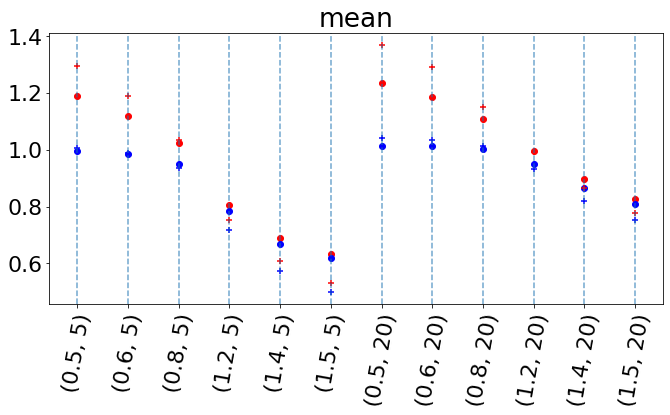

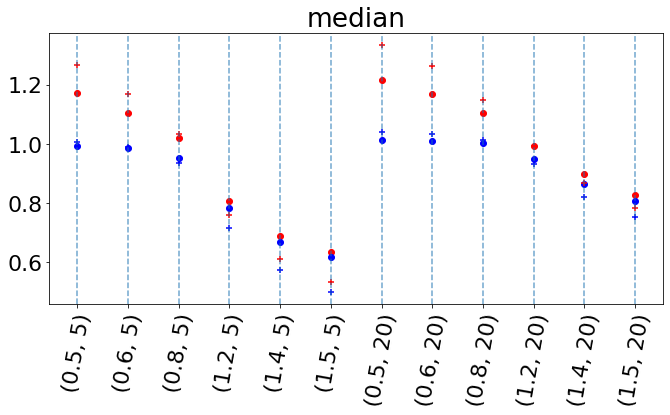

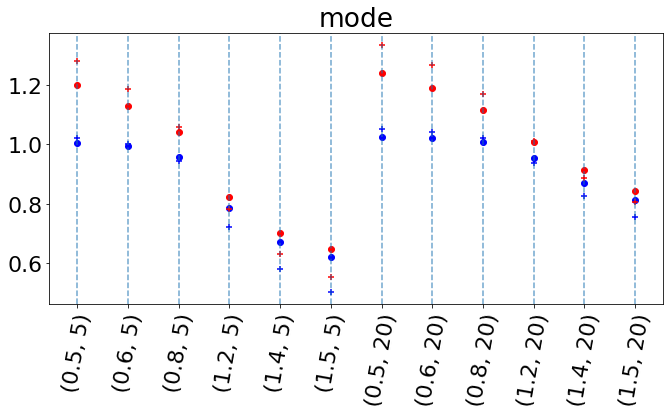

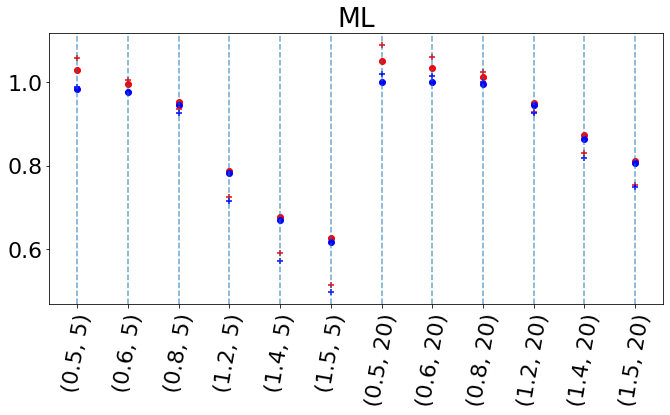

In [7]:
for pe in PE:
    fig, ax = plot_FSE_pe(path, "final", "final_wider", pe, "o")
    
    #props = dict(boxstyle='round', facecolor='grey', alpha=0.2)
    #ax.text(0.45, 0.15, r"$\sigma_T=10\%$ $\sigma_{\rm mass}=\sigma_{\rm radius}=\sigma_{\rm age}=30\%$", 
    #        transform=ax.transAxes, fontsize=18, bbox=props, verticalalignment='top')
    
    #fig.savefig("FSE_MAP_sigma0.3.pdf", bbox_inches="tight")
    plot_FSE_pe(path, "final_non_linear", "final_non_linear_wider", pe, "+", fig, ax)